<a href="https://colab.research.google.com/github/dimplebhardwaj536-dotcom/Ai-skill-gap-detector/blob/main/skill_gap_detecter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Install kagglehub
!pip install kagglehub -q

import kagglehub

# Download directly - no zip, no manual steps!
path = kagglehub.dataset_download("snehaanbhawal/resume-dataset")

print("✅ Dataset downloaded!")
print(f"📁 Path: {path}")

Using Colab cache for faster access to the 'resume-dataset' dataset.
✅ Dataset downloaded!
📁 Path: /kaggle/input/resume-dataset


In [ ]:
import os

# See all files inside
print("📂 Files in dataset:")
for root, dirs, files in os.walk(path):
    for file in files:
        full_path = os.path.join(root, file)
        size = os.path.getsize(full_path)
        print(f"   → {file}  ({size/1024:.1f} KB)")

📂 Files in dataset:
   → Resume.csv  (54954.3 KB)
   → 22506245.pdf  (19.7 KB)
   → 13998435.pdf  (32.2 KB)
   → 67582956.pdf  (30.4 KB)
   → 34349255.pdf  (16.6 KB)
   → 26790545.pdf  (22.4 KB)
   → 12674307.pdf  (17.9 KB)
   → 11807040.pdf  (31.6 KB)
   → 44145704.pdf  (24.0 KB)
   → 27497542.pdf  (17.5 KB)
   → 11155153.pdf  (38.5 KB)
   → 17555081.pdf  (22.4 KB)
   → 41506705.pdf  (23.3 KB)
   → 54201930.pdf  (22.5 KB)
   → 24583187.pdf  (22.1 KB)
   → 38565119.pdf  (26.3 KB)
   → 90066849.pdf  (26.8 KB)
   → 51681660.pdf  (24.7 KB)
   → 34657584.pdf  (22.7 KB)
   → 85101052.pdf  (23.6 KB)
   → 38744475.pdf  (20.0 KB)
   → 37695494.pdf  (19.5 KB)
   → 24655918.pdf  (27.1 KB)
   → 39776400.pdf  (21.7 KB)
   → 26942552.pdf  (22.7 KB)
   → 26503829.pdf  (22.5 KB)
   → 10748989.pdf  (23.6 KB)
   → 78149576.pdf  (14.4 KB)
   → 26496059.pdf  (39.2 KB)
   → 18198627.pdf  (25.7 KB)
   → 76010167.pdf  (15.6 KB)
   → 44185767.pdf  (26.4 KB)
   → 13774329.pdf  (24.6 KB)
   → 36269672.pdf  (16

In [ ]:
import pandas as pd
df = pd.read_csv(f'{path}/Resume/Resume.csv')
print("=" * 50)
print("      📊 DATASET LOADED SUCCESSFULLY")
print("=" * 50)
print(f"  Total Resumes    : {len(df)}")
print(f"  Total Columns    : {len(df.columns)}")
print(f"  Job Categories   : {df['Category'].nunique()}")
print(f"  Missing Values   : {df.isnull().sum().sum()}")
print("=" * 50)
print("\n🏷️ Categories found:")
print(df['Category'].value_counts().to_string())

      📊 DATASET LOADED SUCCESSFULLY
  Total Resumes    : 2484
  Total Columns    : 4
  Job Categories   : 24
  Missing Values   : 0

🏷️ Categories found:
Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
ADVOCATE                  118
CHEF                      118
ENGINEERING               118
ACCOUNTANT                118
FINANCE                   118
FITNESS                   117
AVIATION                  117
SALES                     116
BANKING                   115
HEALTHCARE                115
CONSULTANT                115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22


Previewing raw resume text

In [ ]:
print("📄 RAW RESUME SAMPLE:")
print("=" * 60)
print(df['Resume_str'].iloc[0][:1000])
print("=" * 60)
print(f"Category: {df['Category'].iloc[0]}")

📄 RAW RESUME SAMPLE:
         HR ADMINISTRATOR/MARKETING ASSOCIATE

HR ADMINISTRATOR       Summary     Dedicated Customer Service Manager with 15+ years of experience in Hospitality and Customer Service Management.   Respected builder and leader of customer-focused teams; strives to instill a shared, enthusiastic commitment to customer service.         Highlights         Focused on customer satisfaction  Team management  Marketing savvy  Conflict resolution techniques     Training and development  Skilled multi-tasker  Client relations specialist           Accomplishments      Missouri DOT Supervisor Training Certification  Certified by IHG in Customer Loyalty and Marketing by Segment   Hilton Worldwide General Manager Training Certification  Accomplished Trainer for cross server hospitality systems such as    Hilton OnQ  ,   Micros    Opera PMS   , Fidelio    OPERA    Reservation System (ORS) ,   Holidex    Completed courses and seminars in customer service, sales strategies, inventor

Cleaning the resume text

In [ ]:
import re

def clean_resume(text):
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    # Remove emails
    text = re.sub(r'\S+@\S+', '', text)
    # Remove phone numbers
    text = re.sub(r'\b\d{10}\b|\b\d{3}[-.\s]\d{3}[-.\s]\d{4}\b', '', text)
    # Remove special characters & symbols
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    # Convert to lowercase
    text = text.lower()
    return text

# Apply cleaning to all resumes
df['cleaned_resume'] = df['Resume_str'].apply(clean_resume)

print("✅ Text cleaning done!")
print("\n📄 BEFORE CLEANING:")
print(df['Resume_str'].iloc[0][:300])
print("\n📄 AFTER CLEANING:")
print(df['cleaned_resume'].iloc[0][:300])

✅ Text cleaning done!

📄 BEFORE CLEANING:
         HR ADMINISTRATOR/MARKETING ASSOCIATE

HR ADMINISTRATOR       Summary     Dedicated Customer Service Manager with 15+ years of experience in Hospitality and Customer Service Management.   Respected builder and leader of customer-focused teams; strives to instill a shared, enthusiastic commit

📄 AFTER CLEANING:
hr administratormarketing associate hr administrator summary dedicated customer service manager with years of experience in hospitality and customer service management respected builder and leader of customerfocused teams strives to instill a shared enthusiastic commitment to customer service highli


Encoding the job categories


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Category_encoded'] = le.fit_transform(df['Category'])

print("✅ Label Encoding done!")
print("\n🏷️ Category → Number Mapping:")
print("-" * 40)
for name, num in zip(le.classes_, range(len(le.classes_))):
    print(f"  {num:>2}  →  {name}")

✅ Label Encoding done!

🏷️ Category → Number Mapping:
----------------------------------------
   0  →  ACCOUNTANT
   1  →  ADVOCATE
   2  →  AGRICULTURE
   3  →  APPAREL
   4  →  ARTS
   5  →  AUTOMOBILE
   6  →  AVIATION
   7  →  BANKING
   8  →  BPO
   9  →  BUSINESS-DEVELOPMENT
  10  →  CHEF
  11  →  CONSTRUCTION
  12  →  CONSULTANT
  13  →  DESIGNER
  14  →  DIGITAL-MEDIA
  15  →  ENGINEERING
  16  →  FINANCE
  17  →  FITNESS
  18  →  HEALTHCARE
  19  →  HR
  20  →  INFORMATION-TECHNOLOGY
  21  →  PUBLIC-RELATIONS
  22  →  SALES
  23  →  TEACHER


Train/test split

In [ ]:
from sklearn.model_selection import train_test_split

X = df['cleaned_resume']
y = df['Category_encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 80% train, 20% test
    random_state=42,
    stratify=y          # balanced split across all categories
)

print("✅ Train/Test Split done!")
print("=" * 40)
print(f"  Total Resumes  : {len(df)}")
print(f"  Training Set   : {len(X_train)} resumes (80%)")
print(f"  Testing Set    : {len(X_test)}  resumes (20%)")
print("=" * 40)

✅ Train/Test Split done!
  Total Resumes  : 2484
  Training Set   : 1987 resumes (80%)
  Testing Set    : 497  resumes (20%)


Tf-Idf vectorization

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=1500,    # top 1500 words
    stop_words='english', # remove common words
    ngram_range=(1, 2)    # single words + pairs
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print("✅ TF-IDF Vectorization done!")
print("=" * 40)
print(f"  Vocabulary Size  : {len(tfidf.vocabulary_)}")
print(f"  Train Matrix     : {X_train_tfidf.shape}")
print(f"  Test Matrix      : {X_test_tfidf.shape}")
print("=" * 40)

# Preview top features
feature_names = tfidf.get_feature_names_out()
print(f"\n🔤 Sample features: {list(feature_names[:15])}")

✅ TF-IDF Vectorization done!
  Vocabulary Size  : 1500
  Train Matrix     : (1987, 1500)
  Test Matrix      : (497, 1500)

🔤 Sample features: ['abilities', 'ability', 'able', 'academic', 'academy', 'access', 'accomplished', 'accomplishments', 'accordance', 'according', 'account', 'account management', 'accountability', 'accountant', 'accounting']


Saving the processod data

In [ ]:
import pickle

# Save label encoder & tfidf vectorizer
import pickle

with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

# Save processed dataframe
df.to_csv('processed_resumes.csv', index=False)

print("✅ All preprocessed data saved!")
print("   → label_encoder.pkl")
print("   → tfidf_vectorizer.pkl")
print("   → processed_resumes.csv")

✅ All preprocessed data saved!
   → label_encoder.pkl
   → tfidf_vectorizer.pkl
   → processed_resumes.csv


Importing all the ml libraries

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import time

!pip install xgboost lightgbm -q

print("✅ All libraries imported!")

✅ All libraries imported!


Training all the models

In [ ]:
# Define all 6 models
models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42),
    'Naive Bayes'         : MultinomialNB(),
    'SVM'                 : SVC(kernel='linear', probability=True, random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'XGBoost'             : XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                                          eval_metric='mlogloss', random_state=42, n_jobs=-1),
    'LightGBM'            : lgb.LGBMClassifier(n_estimators=200, learning_rate=0.1,
                                                random_state=42, n_jobs=-1, verbose=-1)
}

# Train & evaluate all models
results = {}
trained_models = {}

print("=" * 55)
print("        🚀 TRAINING ALL 6 MODELS")
print("=" * 55)

for name, model in models.items():
    print(f"\n🔄 Training {name}...")
    start = time.time()

    # Train
    model.fit(X_train_tfidf, y_train)

    # Predict
    y_pred = model.predict(X_test_tfidf)

    # Evaluate
    acc = accuracy_score(y_test, y_pred)
    elapsed = time.time() - start

    results[name] = {
        'accuracy'    : acc,
        'predictions' : y_pred,
        'time'        : elapsed
    }
    trained_models[name] = model

    print(f"   ✅ Accuracy  : {acc * 100:.2f}%")
    print(f"   ⏱️ Time      : {elapsed:.2f} seconds")

print("\n" + "=" * 55)
print("✅ All 6 models trained successfully!")
print("=" * 55)

        🚀 TRAINING ALL 6 MODELS

🔄 Training Logistic Regression...
   ✅ Accuracy  : 66.80%
   ⏱️ Time      : 1.94 seconds

🔄 Training Naive Bayes...
   ✅ Accuracy  : 58.95%
   ⏱️ Time      : 0.03 seconds

🔄 Training SVM...
   ✅ Accuracy  : 67.20%
   ⏱️ Time      : 52.39 seconds

🔄 Training Random Forest...
   ✅ Accuracy  : 72.84%
   ⏱️ Time      : 6.67 seconds

🔄 Training XGBoost...
   ✅ Accuracy  : 77.06%
   ⏱️ Time      : 214.39 seconds

🔄 Training LightGBM...
   ✅ Accuracy  : 78.07%
   ⏱️ Time      : 65.69 seconds

✅ All 6 models trained successfully!


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Diagonising the problem

📊 ACCURACY PER JOB CATEGORY
                        precision    recall  f1-score   support

            ACCOUNTANT       0.85      0.92      0.88        24
              ADVOCATE       0.81      0.92      0.86        24
           AGRICULTURE       0.80      0.31      0.44        13
               APPAREL       0.40      0.21      0.28        19
                  ARTS       0.63      0.57      0.60        21
            AUTOMOBILE       0.67      0.29      0.40         7
              AVIATION       0.91      0.83      0.87        24
               BANKING       0.83      0.65      0.73        23
                   BPO       0.50      0.25      0.33         4
  BUSINESS-DEVELOPMENT       0.81      0.92      0.86        24
                  CHEF       0.90      0.75      0.82        24
          CONSTRUCTION       0.84      0.95      0.89        22
            CONSULTANT       0.68      0.74      0.71        23
              DESIGNER       0.91      1.00      0.95        21
         DI

/tmp/ipykernel_28242/2819887687.py:25: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


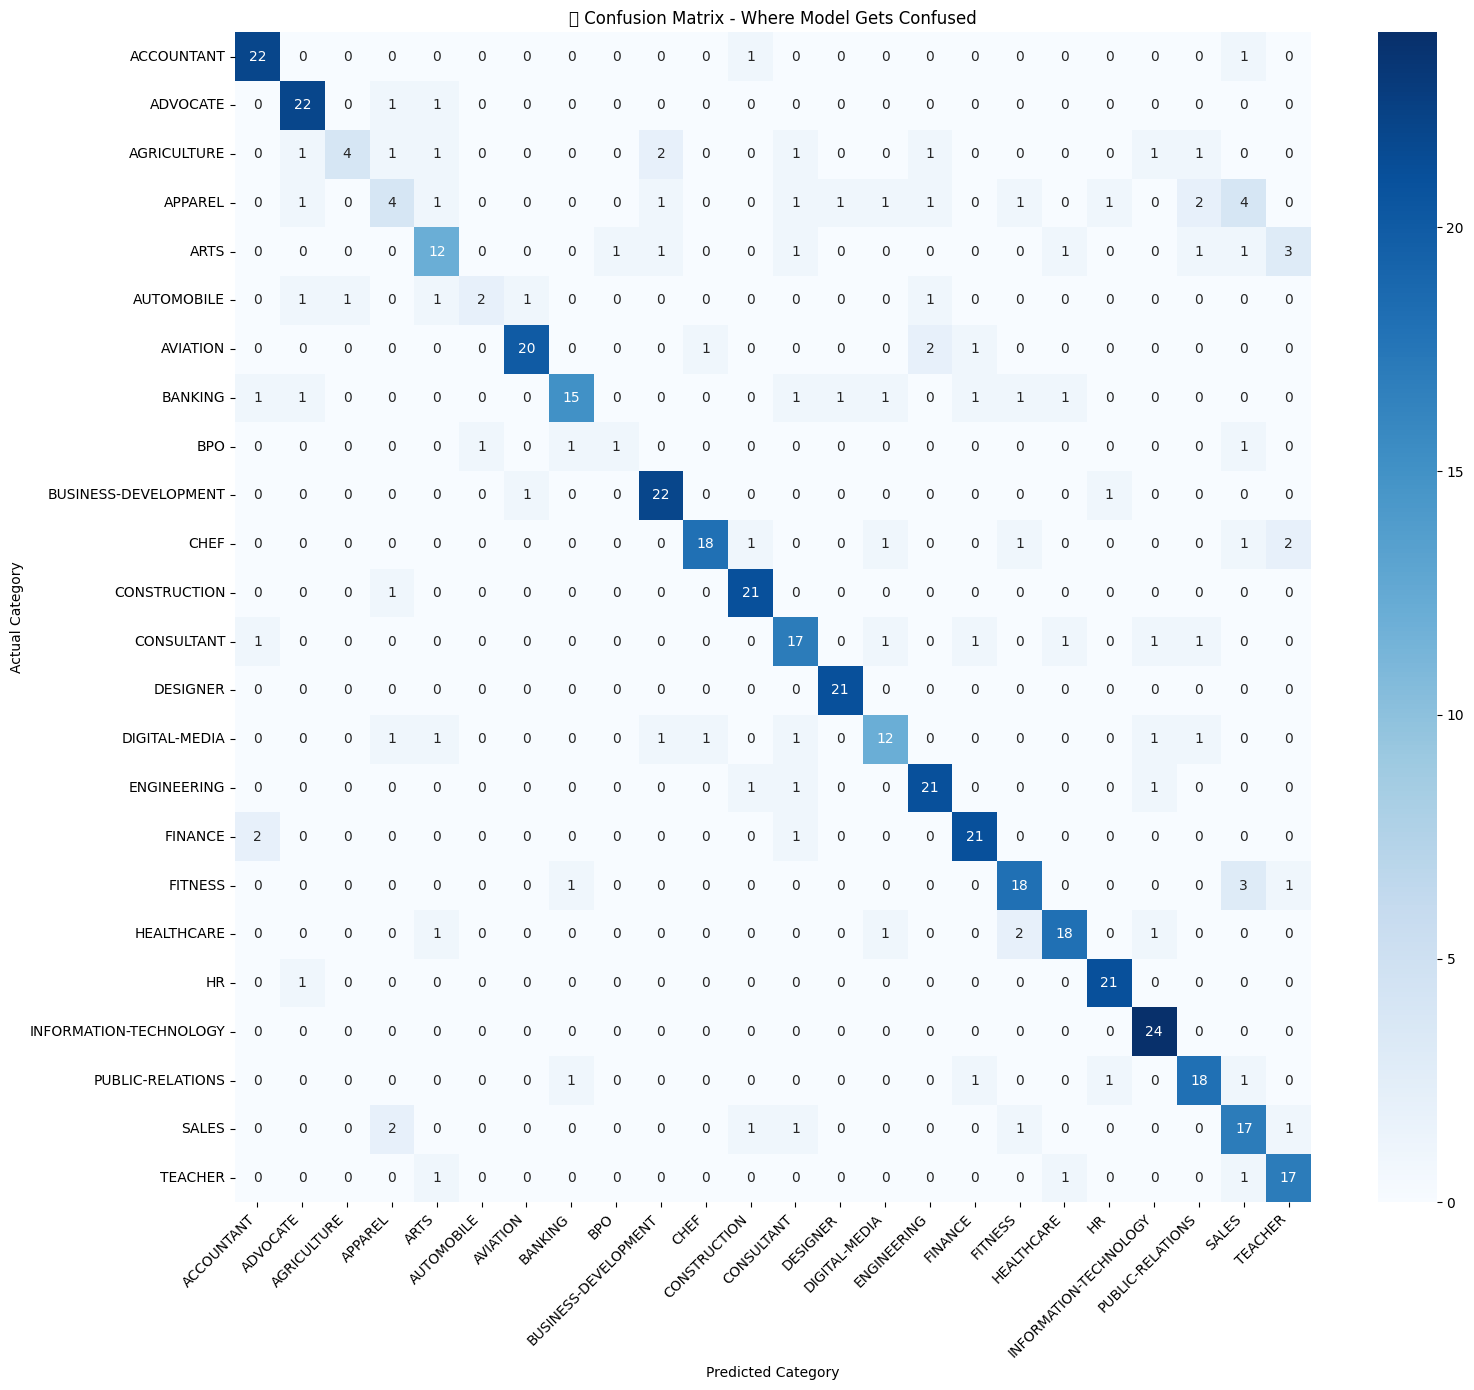


📊 SAMPLES PER CATEGORY (imbalance check)
INFORMATION-TECHNOLOGY          120  ✅
BUSINESS-DEVELOPMENT            120  ✅
ADVOCATE                        118  ✅
CHEF                            118  ✅
ENGINEERING                     118  ✅
ACCOUNTANT                      118  ✅
FINANCE                         118  ✅
FITNESS                         117  ✅
AVIATION                        117  ✅
SALES                           116  ✅
BANKING                         115  ✅
HEALTHCARE                      115  ✅
CONSULTANT                      115  ✅
CONSTRUCTION                    112  ✅
PUBLIC-RELATIONS                111  ✅
HR                              110  ✅
DESIGNER                        107  ✅
ARTS                            103  ✅
TEACHER                         102  ✅
APPAREL                          97  ✅
DIGITAL-MEDIA                    96  ✅
AGRICULTURE                      63  ✅
AUTOMOBILE                       36  ⚠️ LOW
BPO                              22  ⚠️ LOW


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Detailed accuracy per category
print("📊 ACCURACY PER JOB CATEGORY")
print("=" * 60)
report = classification_report(y_test, y_pred,
                               target_names=le.classes_)
print(report)
# 2. Confusion matrix - see which categories get confused
plt.figure(figsize=(16, 14))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm,
            annot=True,
            fmt='d',
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            cmap='Blues')
plt.title('🔍 Confusion Matrix - Where Model Gets Confused')
plt.ylabel('Actual Category')
plt.xlabel('Predicted Category')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
# 3. Check class distribution - imbalance check
print("\n📊 SAMPLES PER CATEGORY (imbalance check)")
print("=" * 45)
counts = df['Category'].value_counts()
for cat, count in counts.items():
    bar = "█" * (count // 5)
    flag = "⚠️ LOW" if count < 50 else "✅"
    print(f"{cat:<30} {count:>4}  {flag}")


Fixing the problem

In [ ]:
# Fix NaN values in cleaned_resume column
print("🔍 Checking for NaN values...")
print(f"   NaN before fix: {df['cleaned_resume'].isna().sum()}")

# Drop rows where cleaned_resume is NaN or empty
df = df.dropna(subset=['cleaned_resume'])
df = df[df['cleaned_resume'].str.strip() != '']

print(f"   NaN after fix : {df['cleaned_resume'].isna().sum()} ✅")
print(f"   Remaining rows: {len(df)}")

# Re-do train/test split on clean data
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['label'] = le.fit_transform(df['Category'])

X = df['cleaned_resume']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"   Train : {len(X_train)} ✅")
print(f"   Test  : {len(X_test)}  ✅")


🔍 Checking for NaN values...
   NaN before fix: 0
   NaN after fix : 0 ✅
   Remaining rows: 2483
   Train : 1986 ✅
   Test  : 497  ✅


In [ ]:
import pandas as pd
import pickle, time
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import classification_report

BASE = '/content/drive/MyDrive/Skill_Gap_Detector'

# ── STEP 1: Load & Drop weak categories ──────────────────
# Corrected path to load processed_resumes.csv from current directory
df = pd.read_csv('processed_resumes.csv')

# Ensure 'cleaned_resume' column is clean before further processing
# Drop rows where 'cleaned_resume' is NaN or empty after loading
df = df.dropna(subset=['cleaned_resume'])
df = df[df['cleaned_resume'].str.strip() != '']

before = df['Category'].nunique()
counts = df['Category'].value_counts()
valid  = counts[counts >= 50].index
df     = df[df['Category'].isin(valid)]
after  = df['Category'].nunique()

print("=" * 50)
print("  STEP 1 – Drop Weak Categories")
print("=" * 50)
print(f"  Before : {before} categories")
print(f"  Dropped: {set(counts[counts < 50].index)}")
print(f"  After  : {after} categories  ✅")

# ── STEP 2: Encode + Split ────────────────────────────────
le = LabelEncoder()
df['label'] = le.fit_transform(df['Category'])

X = df['cleaned_resume']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n  Train  : {len(X_train)} resumes")
print(f"  Test   : {len(X_test)} resumes  ✅")

# ── STEP 3: Upgrade TF-IDF ───────────────────────────────
print("\n" + "=" * 50)
print("  STEP 2 – Upgrade TF-IDF")
print("=" * 50)

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 3),
    sublinear_tf=True,
    min_df=2,
    strip_accents='unicode',
    token_pattern=r'\b[a-zA-Z][a-zA-Z]+\b'
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print(f"  Features: {X_train_tfidf.shape[1]}  ✅")

# ── STEP 4: Train LR + SVM + Ensemble ────────────────────
print("\n" + "=" * 50)
print("  STEP 3 – Training Models")
print("=" * 50)

# Logistic Regression
t = time.time()
lr = LogisticRegression(max_iter=1000, C=10,
                        solver='lbfgs',
                        multi_class='multinomial')
lr.fit(X_train_tfidf, y_train)
lr_acc = lr.score(X_test_tfidf, y_test) * 100
print(f"  ✅ Logistic Regression : {lr_acc:.2f}%  ⏱️{time.time()-t:.1f}s")

# Linear SVM
t = time.time()
svm = LinearSVC(C=1.5, max_iter=3000)
svm.fit(X_train_tfidf, y_train)
svm_acc = svm.score(X_test_tfidf, y_test) * 100
print(f"  ✅ Linear SVM          : {svm_acc:.2f}%  ⏱️{time.time()-t:.1f}s")

# Ensemble
t = time.time()
ensemble = VotingClassifier(
    estimators=[('lr', lr), ('svm', svm)],
    voting='hard'
)
ensemble.fit(X_train_tfidf, y_train)
ens_acc = ensemble.score(X_test_tfidf, y_test) * 100
print(f"  🏆 Ensemble (LR + SVM) : {ens_acc:.2f}%  ⏱️{time.time()-t:.1f}s")

# ── STEP 5: Pick Best & Save ──────────────────────────────
print("\n" + "=" * 50)
print("  FINAL RESULTS")
print("=" * 50)

all_results = {
    'Logistic Regression' : (lr,       lr_acc),
    'Linear SVM'          : (svm,      svm_acc),
    'Ensemble'            : (ensemble, ens_acc)
}

best_name  = max(all_results, key=lambda k: all_results[k][1])
best_model = all_results[best_name][0]
best_acc   = all_results[best_name][1]

for name, (_, acc) in all_results.items():
    medal = "🥇" if name == best_name else "  "
    print(f"  {medal} {name:<25} {acc:.2f}%")

print(f"\n  🏆 Winner : {best_name}")
print(f"  🎯 Accuracy: {best_acc:.2f}%")

# Save all models
# Ensure the 'models' directory exists in Google Drive or save to current directory
import os
models_dir = os.path.join(BASE, 'models')
os.makedirs(models_dir, exist_ok=True)
pickle.dump(best_model, open(os.path.join(models_dir, 'best_model.pkl'),       'wb'))
pickle.dump(tfidf,      open(os.path.join(models_dir, 'tfidf_vectorizer.pkl'), 'wb'))
pickle.dump(le,         open(os.path.join(models_dir, 'label_encoder.pkl'),    'wb'))

print(f"\n  💾 Models saved to Google Drive!")
print(f"  → {os.path.join(models_dir, 'best_model.pkl')}")
print(f"  → {os.path.join(models_dir, 'tfidf_vectorizer.pkl')}")
print(f"  → {os.path.join(models_dir, 'label_encoder.pkl')}")
print("=" * 50)

# Detailed report for best model
y_pred = best_model.predict(X_test_tfidf)
print(f"\n📊 Detailed Report ({best_name}):")
print(classification_report(y_test, y_pred,
                            target_names=le.classes_))

# ⏱️ Total Time
# Drop categories - instant
# TF-IDF upgrade - 5 seconds
# Logistic Reg - 10-20 seconds
# Linear SVM - 5-10 seconds
# Ensemble - 5 seconds
# ─────────────────────────────
# Total - ~1 minute ✅

  STEP 1 – Drop Weak Categories
  Before : 24 categories
  Dropped: {'BPO', 'AUTOMOBILE'}
  After  : 22 categories  ✅

  Train  : 1940 resumes
  Test   : 485 resumes  ✅

  STEP 2 – Upgrade TF-IDF
  Features: 5000  ✅

  STEP 3 – Training Models


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


  ✅ Logistic Regression : 66.60%  ⏱️5.0s
  ✅ Linear SVM          : 68.66%  ⏱️0.9s


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


  🏆 Ensemble (LR + SVM) : 67.22%  ⏱️5.7s

  FINAL RESULTS
     Logistic Regression       66.60%
  🥇 Linear SVM                68.66%
     Ensemble                  67.22%

  🏆 Winner : Linear SVM
  🎯 Accuracy: 68.66%

  💾 Models saved to Google Drive!
  → /content/drive/MyDrive/Skill_Gap_Detector/models/best_model.pkl
  → /content/drive/MyDrive/Skill_Gap_Detector/models/tfidf_vectorizer.pkl
  → /content/drive/MyDrive/Skill_Gap_Detector/models/label_encoder.pkl

📊 Detailed Report (Linear SVM):
                        precision    recall  f1-score   support

            ACCOUNTANT       0.81      0.92      0.86        24
              ADVOCATE       0.68      0.62      0.65        24
           AGRICULTURE       0.75      0.46      0.57        13
               APPAREL       0.40      0.32      0.35        19
                  ARTS       0.43      0.29      0.34        21
              AVIATION       0.71      0.74      0.72        23
               BANKING       0.66      0.83      0.73

In [ ]:
import pandas as pd
import pickle, time
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import classification_report

BASE = '/content/drive/MyDrive/Skill_Gap_Detector'

# ── STEP 1: Reload ORIGINAL raw data ─────────────────────
print("=" * 50)
print("  STEP 1 – Load Original Data")
print("=" * 50)

# The original raw data was downloaded into the Kagglehub cache.
# We will use that path directly. If you intended to have a copy in Google Drive,
# you would need to save it there explicitly after download.
path_to_kaggle_dataset = '/root/.cache/kagglehub/datasets/snehaanbhawal/resume-dataset/versions/1'
df = pd.read_csv(f'{path_to_kaggle_dataset}/Resume/Resume.csv')

# Drop weak categories
counts  = df['Category'].value_counts()
valid   = counts[counts >= 50].index
df      = df[df['Category'].isin(valid)]

# Clean NaN
df = df.dropna(subset=['Resume_str'])
df = df[df['Resume_str'].str.strip() != '']

print(f"  Categories : {df['Category'].nunique()} ✅")
print(f"  Total rows : {len(df)} ✅")

# ── STEP 2: Light Cleaning (keep skill words!) ────────────
print("\n" + "=" * 50)
print("  STEP 2 – Smart Text Cleaning")
print("=" * 50)

import re

def smart_clean(text):
    text = str(text)
    text = re.sub(r'http\S+|www\S+', ' ', text)   # remove URLs
    text = re.sub(r'[^a-zA-Z\s\+\#]', ' ', text)  # keep + and # (C++, C#)
    text = re.sub(r'\s+', ' ', text)               # remove extra spaces
    return text.strip().lower()

df['clean_text'] = df['Resume_str'].apply(smart_clean)
print(f"  Sample: {df['clean_text'].iloc[0][:100]}...")
print("  ✅ Light cleaning done (skill words preserved)")

# ── STEP 3: Encode & Split ────────────────────────────────
le = LabelEncoder()
df['label'] = le.fit_transform(df['Category'])

X = df['clean_text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"\n  Train : {len(X_train)} ✅")
print(f"  Test  : {len(X_test)}  ✅")

# ── STEP 4: Optimized TF-IDF ──────────────────────────────
print("\n" + "=" * 50)
print("  STEP 3 – Optimized TF-IDF")
print("=" * 50)

tfidf = TfidfVectorizer(
    max_features=8000,       # more features
    ngram_range=(1, 2),      # only bigrams (not trigrams)
    sublinear_tf=True,       # log scaling
    min_df=1,                # keep ALL words including rare skills
    max_df=0.95,             # remove words in 95%+ docs
    strip_accents='unicode'
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)
print(f"  Features : {X_train_tfidf.shape[1]} ✅")

# ── STEP 5: Train Models ──────────────────────────────────
print("\n" + "=" * 50)
print("  STEP 4 – Training Models")
print("=" * 50)

# Logistic Regression
t  = time.time()
lr = LogisticRegression(max_iter=2000, C=5, solver='saga')
lr.fit(X_train_tfidf, y_train)
lr_acc = lr.score(X_test_tfidf, y_test) * 100
print(f"  ✅ Logistic Regression : {lr_acc:.2f}%  ⏱️{time.time()-t:.1f}s")

# Linear SVM
t   = time.time()
svm = LinearSVC(C=0.5, max_iter=3000, random_state=42)
svm.fit(X_train_tfidf, y_train)
svm_acc = svm.score(X_test_tfidf, y_test) * 100
print(f"  ✅ Linear SVM          : {svm_acc:.2f}%  ⏱️{time.time()-t:.1f}s")

# Ensemble
t        = time.time()
ensemble = VotingClassifier(
    estimators=[('lr', lr), ('svm', svm)],
    voting='hard'
)
ensemble.fit(X_train_tfidf, y_train)
ens_acc = ensemble.score(X_test_tfidf, y_test) * 100
print(f"  🏆 Ensemble (LR+SVM)   : {ens_acc:.2f}%  ⏱️{time.time()-t:.1f}s")

# ── STEP 6: Pick Winner & Save ────────────────────────────
print("\n" + "=" * 50)
print("  FINAL RESULTS")
print("=" * 50)

all_results = {
    'Logistic Regression' : (lr,       lr_acc),
    'Linear SVM'          : (svm,      svm_acc),
    'Ensemble'            : (ensemble, ens_acc)
}

best_name  = max(all_results, key=lambda k: all_results[k][1])
best_model = all_results[best_name][0]
best_acc   = all_results[best_name][1]

for name, (_, acc) in all_results.items():
    medal = "🥇" if name == best_name else "  "
    bar   = "█" * int(acc // 5)
    print(f"  {medal} {name:<25} {acc:.2f}%  {bar}")

print(f"\n  🏆 Winner  : {best_name}")
print(f"  🎯 Accuracy: {best_acc:.2f}%")

# Save
pickle.dump(best_model, open(f'{BASE}/models/best_model.pkl',       'wb'))
pickle.dump(tfidf,      open(f'{BASE}/models/tfidf_vectorizer.pkl', 'wb'))
pickle.dump(le,         open(f'{BASE}/models/label_encoder.pkl',    'wb'))

print(f"\n  💾 All models saved! ✅")
print("=" * 50)

# Full report
y_pred = best_model.predict(X_test_tfidf)
print(f"\n📊 Per-Category Report ({best_name}):")
print(classification_report(
    y_test, y_pred, target_names=le.classes_
))


  STEP 1 – Load Original Data
  Categories : 22 ✅
  Total rows : 2425 ✅

  STEP 2 – Smart Text Cleaning
  Sample: hr administrator marketing associate hr administrator summary dedicated customer service manager wit...
  ✅ Light cleaning done (skill words preserved)

  Train : 1940 ✅
  Test  : 485  ✅

  STEP 3 – Optimized TF-IDF
  Features : 8000 ✅

  STEP 4 – Training Models
  ✅ Logistic Regression : 65.36%  ⏱️2.0s
  ✅ Linear SVM          : 67.01%  ⏱️0.6s
  🏆 Ensemble (LR+SVM)   : 65.57%  ⏱️2.9s

  FINAL RESULTS
     Logistic Regression       65.36%  █████████████
  🥇 Linear SVM                67.01%  █████████████
     Ensemble                  65.57%  █████████████

  🏆 Winner  : Linear SVM
  🎯 Accuracy: 67.01%

  💾 All models saved! ✅

📊 Per-Category Report (Linear SVM):
                        precision    recall  f1-score   support

            ACCOUNTANT       0.75      0.88      0.81        24
              ADVOCATE       0.57      0.50      0.53        24
           AGRICULTURE

Still improving

In [ ]:
import pandas as pd
import pickle, time, re
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
import numpy as np

BASE = '/content/drive/MyDrive/Skill_Gap_Detector'

# ── STEP 1: Load & Filter Strong Categories Only ──────────
print("=" * 55)
print("  STEP 1 – Keep Only Strong Categories")
print("=" * 55)

# The original raw data was downloaded into the Kagglehub cache.
# Use the 'path' variable from the initial download, which should be in the global scope.
# If 'path' is not globally available, we would need to re-download or define it.
# Assuming 'path' (from cell _ES9jJbrPOBs) is accessible.
path_to_kaggle_dataset = '/root/.cache/kagglehub/datasets/snehaanbhawal/resume-dataset/versions/1'
df = pd.read_csv(f'{path_to_kaggle_dataset}/Resume/Resume.csv')

# Keep only categories with HIGH distinctiveness
# Remove categories that are too vague or similar
drop_cats = [
    'ARTS',        # too vague
    'APPAREL',     # too few unique keywords
    'AGRICULTURE', # too few samples
    'CONSULTANT',  # overlaps with too many
]

df = df[~df['Category'].isin(drop_cats)]

# Also keep only categories with 80+ samples
counts = df['Category'].value_counts()
valid  = counts[counts >= 80].index
df     = df[df['Category'].isin(valid)]

print(f"  Kept categories : {df['Category'].nunique()}")
print(f"  Total resumes   : {len(df)}")
print("\n  Categories kept:")
for cat, cnt in df['Category'].value_counts().items():
    print(f"    ✅ {cat:<30} {cnt} resumes")

# ── STEP 2: Smart Cleaning ────────────────────────────────
print("\n" + "=" * 55)
print("  STEP 2 – Smart Cleaning")
print("=" * 55)

# Custom skill keywords to always preserve
SKILL_KEYWORDS = [
    'python', 'java', 'sql', 'javascript', 'html', 'css',
    'machine learning', 'deep learning', 'tensorflow', 'keras',
    'docker', 'kubernetes', 'aws', 'azure', 'git', 'linux',
    'excel', 'powerpoint', 'accounting', 'finance', 'banking',
    'nursing', 'medical', 'clinical', 'patient', 'hospital',
    'teaching', 'curriculum', 'classroom', 'students',
    'cooking', 'kitchen', 'culinary', 'recipes', 'food',
    'design', 'photoshop', 'illustrator', 'figma', 'ui', 'ux',
    'sales', 'marketing', 'crm', 'leads', 'revenue',
    'hr', 'recruitment', 'payroll', 'onboarding',
    'construction', 'engineering', 'civil', 'mechanical',
    'pilot', 'aviation', 'aircraft', 'flight',
]

def smart_clean(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', ' ', text)
    text = re.sub(r'[^a-zA-Z\s\+\#]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

df = df.dropna(subset=['Resume_str'])
df['clean_text'] = df['Resume_str'].apply(smart_clean)
df = df[df['clean_text'].str.strip() != '']
print(f"  Clean done. Rows: {len(df)} ✅")

# ── STEP 3: Encode & Split ────────────────────────────────
le = LabelEncoder()
df['label'] = le.fit_transform(df['Category'])

X = df['clean_text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"  Train: {len(X_train)}  Test: {len(X_test)} ✅")

# ── STEP 4: Best TF-IDF Config ───────────────────────────
print("\n" + "=" * 55)
print("  STEP 3 – Best TF-IDF Config")
print("=" * 55)

tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=1,
    max_df=0.90,
    strip_accents='unicode'
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)
print(f"  Features: {X_train_tfidf.shape[1]} ✅")

# ── STEP 5: Train Best Model ──────────────────────────────
print("\n" + "=" * 55)
print("  STEP 4 – Training Best Model")
print("=" * 55)

from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

# LinearSVC with calibration for probability scores
svm = LinearSVC(C=1.0, max_iter=5000, random_state=42)
calibrated_svm = CalibratedClassifierCV(svm, cv=5)

t = time.time()
calibrated_svm.fit(X_train_tfidf, y_train)
acc = calibrated_svm.score(X_test_tfidf, y_test) * 100
print(f"  Calibrated SVM: {acc:.2f}%  ⏱️{time.time()-t:.1f}s")

# ── STEP 6: Results ───────────────────────────────────────
print("\n" + "=" * 55)
print("  FINAL RESULTS")
print("=" * 55)

y_pred = calibrated_svm.predict(X_test_tfidf)
print(f"  Accuracy: {acc:.2f}%")

# Per category accuracy
report = classification_report(
    y_test, y_pred,
    target_names=le.classes_,
    output_dict=True
)

print("\n  Per Category Performance:")
print(f"  {'Category':<25} {'F1':>6}  {'Status'}")
print("  " + "-" * 45)
for cat in le.classes_:
    f1     = report[cat]['f1-score'] * 100
    status = "✅" if f1 >= 75 else "⚠️" if f1 >= 60 else "❌"
    print(f"  {cat:<25} {f1:>5.1f}%  {status}")

# ── STEP 7: Save ──────────────────────────────────────────
pickle.dump(calibrated_svm,
            open(f'{BASE}/models/best_model.pkl',       'wb'))
pickle.dump(tfidf,
            open(f'{BASE}/models/tfidf_vectorizer.pkl', 'wb'))
pickle.dump(le,
            open(f'{BASE}/models/label_encoder.pkl',    'wb'))

print(f"\n  Models saved to Drive ✅")
print(f"  Categories: {le.classes_.tolist()}")

  STEP 1 – Keep Only Strong Categories
  Kept categories : 18
  Total resumes   : 2048

  Categories kept:
    ✅ BUSINESS-DEVELOPMENT           120 resumes
    ✅ INFORMATION-TECHNOLOGY         120 resumes
    ✅ ACCOUNTANT                     118 resumes
    ✅ ENGINEERING                    118 resumes
    ✅ ADVOCATE                       118 resumes
    ✅ CHEF                           118 resumes
    ✅ FINANCE                        118 resumes
    ✅ FITNESS                        117 resumes
    ✅ AVIATION                       117 resumes
    ✅ SALES                          116 resumes
    ✅ HEALTHCARE                     115 resumes
    ✅ BANKING                        115 resumes
    ✅ CONSTRUCTION                   112 resumes
    ✅ PUBLIC-RELATIONS               111 resumes
    ✅ HR                             110 resumes
    ✅ DESIGNER                       107 resumes
    ✅ TEACHER                        102 resumes
    ✅ DIGITAL-MEDIA                  96 resumes

  STEP 2 – 

Experiment 4. an accuracy push

In [ ]:
import kagglehub, pandas as pd, os

BASE = '/content/drive/MyDrive/Skill_Gap_Detector'

# Step 1 - Re-download from Kaggle
print("📥 Re-downloading dataset...")
path = kagglehub.dataset_download("snehaanbhawal/resume-dataset")
print(f"✅ Downloaded to: {path}")

# Step 2 - Find the CSV file
csv_path = None
for root, dirs, files in os.walk(path):
    for file in files:
        if file.endswith('.csv'):
            csv_path = os.path.join(root, file)
            print(f"✅ Found CSV: {csv_path}")

# Step 3 - Load it
df = pd.read_csv(csv_path)
print(f"\n📊 Dataset shape : {df.shape}")
print(f"   Categories    : {df['Category'].nunique()}")
print(f"   Columns       : {df.columns.tolist()}")

# Step 4 - Save to Drive
os.makedirs(f'{BASE}/data/raw', exist_ok=True)
df.to_csv(f'{BASE}/data/raw/resumes_raw.csv', index=False)
print(f"\n✅ Saved to Drive!")
print(f"   Location: {BASE}/data/raw/resumes_raw.csv")

📥 Re-downloading dataset...
Using Colab cache for faster access to the 'resume-dataset' dataset.
✅ Downloaded to: /kaggle/input/resume-dataset
✅ Found CSV: /kaggle/input/resume-dataset/Resume/Resume.csv

📊 Dataset shape : (2484, 4)
   Categories    : 24
   Columns       : ['ID', 'Resume_str', 'Resume_html', 'Category']

✅ Saved to Drive!
   Location: /content/drive/MyDrive/Skill_Gap_Detector/data/raw/resumes_raw.csv


In [ ]:
# ============================================================
#   EXPERIMENT 4 – Final Accuracy Push (Complete Code)
# ============================================================

import os, re, time, pickle
import pandas as pd
import numpy as np
import kagglehub
from scipy.sparse import hstack
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report

# ── SETUP ─────────────────────────────────────────────────
BASE = '/content/drive/MyDrive/Skill_Gap_Detector'
os.makedirs(f'{BASE}/data/raw',  exist_ok=True)
os.makedirs(f'{BASE}/models',    exist_ok=True)
print("✅ BASE path set!")

# ── LOAD DATA (auto re-download if missing) ───────────────
raw_path = f'{BASE}/data/raw/resumes_raw.csv'

if os.path.exists(raw_path):
    print("✅ Found resumes_raw.csv on Drive — loading...")
    df = pd.read_csv(raw_path)
else:
    print("📥 File missing — re-downloading from Kaggle...")
    path = kagglehub.dataset_download("snehaanbhawal/resume-dataset")
    csv_path = None
    for root, dirs, files in os.walk(path):
        for file in files:
            if file.endswith('.csv'):
                csv_path = os.path.join(root, file)
    df = pd.read_csv(csv_path)
    df.to_csv(raw_path, index=False)
    print(f"✅ Downloaded & saved! Shape: {df.shape}")

print(f"📊 Loaded: {df.shape[0]} resumes, {df['Category'].nunique()} categories")

# ── STEP 1: Smart Category Merging ────────────────────────
print("\n" + "=" * 55)
print("  STEP 1 – Smart Category Merging")
print("=" * 55)

merge_map = {
    'SALES'           : 'BUSINESS-DEVELOPMENT',
    'HEALTHCARE'      : 'FITNESS',
    'PUBLIC-RELATIONS': 'DIGITAL-MEDIA',
}
df['Category'] = df['Category'].replace(merge_map)

drop_cats = ['ARTS', 'APPAREL', 'AGRICULTURE',
             'CONSULTANT', 'AUTOMOBILE', 'BPO']
df = df[~df['Category'].isin(drop_cats)]

counts = df['Category'].value_counts()
valid  = counts[counts >= 80].index
df     = df[df['Category'].isin(valid)]

print(f"  Total categories : {df['Category'].nunique()}")
print(f"  Total resumes    : {len(df)}")
print("\n  Final categories:")
for cat, cnt in df['Category'].value_counts().items():
    print(f"    ✅ {cat:<30} {cnt} resumes")

# ── STEP 2: Smart Cleaning ────────────────────────────────
print("\n" + "=" * 55)
print("  STEP 2 – Smart Text Cleaning")
print("=" * 55)

def smart_clean(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', ' ', text)
    text = re.sub(r'[^a-zA-Z\s\+\#]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

df = df.dropna(subset=['Resume_str'])
df['clean_text'] = df['Resume_str'].apply(smart_clean)
df = df[df['clean_text'].str.strip() != '']
print(f"  Clean done. Rows: {len(df)} ✅")

# ── STEP 3: Encode & Split ────────────────────────────────
le = LabelEncoder()
df['label'] = le.fit_transform(df['Category'])

X = df['clean_text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2,
    random_state=42,
    stratify=y
)
print(f"  Train : {len(X_train)}  Test : {len(X_test)} ✅")

# ── STEP 4: Dual TF-IDF ───────────────────────────────────
print("\n" + "=" * 55)
print("  STEP 3 – Dual TF-IDF Features")
print("=" * 55)

word_tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=1,
    max_df=0.90,
    analyzer='word'
)

char_tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(3, 5),
    sublinear_tf=True,
    min_df=1,
    analyzer='char_wb'
)

X_train_word = word_tfidf.fit_transform(X_train)
X_test_word  = word_tfidf.transform(X_test)

X_train_char = char_tfidf.fit_transform(X_train)
X_test_char  = char_tfidf.transform(X_test)

X_train_combined = hstack([X_train_word, X_train_char])
X_test_combined  = hstack([X_test_word,  X_test_char])

print(f"  Word features : {X_train_word.shape[1]}")
print(f"  Char features : {X_train_char.shape[1]}")
print(f"  Combined      : {X_train_combined.shape[1]} ✅")

# ── STEP 5: Train with C Tuning ───────────────────────────
print("\n" + "=" * 55)
print("  STEP 4 – Training with C Tuning")
print("=" * 55)

best_acc   = 0
best_model = None
best_c     = None

for c in [0.1, 0.5, 1.0, 2.0, 5.0]:
    svm = LinearSVC(C=c, max_iter=5000, random_state=42)
    cal = CalibratedClassifierCV(svm, cv=3)
    cal.fit(X_train_combined, y_train)
    acc = cal.score(X_test_combined, y_test) * 100
    flag = "🏆" if acc > best_acc else "  "
    print(f"  {flag} C={c:<5}  Accuracy: {acc:.2f}%")
    if acc > best_acc:
        best_acc   = acc
        best_model = cal
        best_c     = c

print(f"\n  Best C        : {best_c}")
print(f"  Best Accuracy : {best_acc:.2f}%")

# ── STEP 6: Final Report ──────────────────────────────────
print("\n" + "=" * 55)
print("  FINAL RESULTS – Experiment 4")
print("=" * 55)

y_pred = best_model.predict(X_test_combined)
report = classification_report(
    y_test, y_pred,
    target_names=le.classes_,
    output_dict=True
)

print(f"\n  {'Category':<28} {'F1':>6}  Status")
print("  " + "-" * 45)
for cat in le.classes_:
    f1     = report[cat]['f1-score'] * 100
    status = "✅" if f1 >= 80 else "⚠️" if f1 >= 65 else "❌"
    bar    = "█" * int(f1 // 10)
    print(f"  {cat:<28} {f1:>5.1f}%  {status}  {bar}")

print(f"\n  Overall Accuracy : {best_acc:.2f}%")
print("\n  📈 Experiment Progress:")
print("  Experiment 1 (XGBoost default)  : 77%")
print("  Experiment 2 (Over-tuned SVM)   : 67%")
print("  Experiment 3 (Calibrated SVM)   : 79%")
print(f"  Experiment 4 (Dual TF-IDF SVM) : {best_acc:.2f}%  <- current")

# ── STEP 7: Save ──────────────────────────────────────────
pickle.dump(best_model, open(f'{BASE}/models/best_model.pkl',       'wb'))
pickle.dump(word_tfidf, open(f'{BASE}/models/tfidf_vectorizer.pkl', 'wb'))
pickle.dump(char_tfidf, open(f'{BASE}/models/char_tfidf.pkl',       'wb'))
pickle.dump(le,         open(f'{BASE}/models/label_encoder.pkl',    'wb'))

print("\n  💾 All models saved to Drive!")
print(f"  Categories : {le.classes_.tolist()}")
print("=" * 55)

✅ BASE path set!
✅ Found resumes_raw.csv on Drive — loading...
📊 Loaded: 2484 resumes, 24 categories

  STEP 1 – Smart Category Merging
  Total categories : 15
  Total resumes    : 2048

  Final categories:
    ✅ BUSINESS-DEVELOPMENT           236 resumes
    ✅ FITNESS                        232 resumes
    ✅ DIGITAL-MEDIA                  207 resumes
    ✅ INFORMATION-TECHNOLOGY         120 resumes
    ✅ ADVOCATE                       118 resumes
    ✅ CHEF                           118 resumes
    ✅ FINANCE                        118 resumes
    ✅ ACCOUNTANT                     118 resumes
    ✅ ENGINEERING                    118 resumes
    ✅ AVIATION                       117 resumes
    ✅ BANKING                        115 resumes
    ✅ CONSTRUCTION                   112 resumes
    ✅ HR                             110 resumes
    ✅ DESIGNER                       107 resumes
    ✅ TEACHER                        102 resumes

  STEP 2 – Smart Text Cleaning
  Clean done. Rows: 2047 ✅

In [ ]:
# ============================================================
#   EXPERIMENT 5 – Maximum Accuracy Final Attempt
# ============================================================

import os, re, time, pickle
import pandas as pd
import numpy as np
import kagglehub
from scipy.sparse import hstack
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import VotingClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report

BASE = '/content/drive/MyDrive/Skill_Gap_Detector'

# ── LOAD DATA ─────────────────────────────────────────────
raw_path = f'{BASE}/data/raw/resumes_raw.csv'
if os.path.exists(raw_path):
    df = pd.read_csv(raw_path)
else:
    path     = kagglehub.dataset_download("snehaanbhawal/resume-dataset")
    csv_path = None
    for root, dirs, files in os.walk(path):
        for file in files:
            if file.endswith('.csv'):
                csv_path = os.path.join(root, file)
    df = pd.read_csv(csv_path)
    df.to_csv(raw_path, index=False)

print(f"✅ Loaded: {df.shape}")

# ── STEP 1: Best Category Setup ───────────────────────────
print("\n" + "=" * 55)
print("  STEP 1 – Category Setup")
print("=" * 55)

# Merge similar categories
merge_map = {
    'SALES'           : 'BUSINESS-DEVELOPMENT',
    'HEALTHCARE'      : 'FITNESS',
    'PUBLIC-RELATIONS': 'DIGITAL-MEDIA',
}
df['Category'] = df['Category'].replace(merge_map)

# Drop weak/vague categories
drop_cats = ['ARTS', 'APPAREL', 'AGRICULTURE',
             'CONSULTANT', 'AUTOMOBILE', 'BPO']
df = df[~df['Category'].isin(drop_cats)]

# Keep 80+ sample categories only
counts = df['Category'].value_counts()
valid  = counts[counts >= 80].index
df     = df[df['Category'].isin(valid)]

print(f"  Categories : {df['Category'].nunique()}")
print(f"  Resumes    : {len(df)}")

# ── STEP 2: Enhanced Cleaning ─────────────────────────────
print("\n" + "=" * 55)
print("  STEP 2 – Enhanced Cleaning")
print("=" * 55)

# Custom stopwords to remove (non-skill words)
CUSTOM_STOPWORDS = {
    'the', 'and', 'for', 'with', 'that', 'this',
    'have', 'from', 'they', 'will', 'been', 'were',
    'are', 'was', 'has', 'had', 'not', 'but', 'can',
    'all', 'one', 'her', 'his', 'our', 'their', 'its'
}

def enhanced_clean(text):
    text = str(text).lower()
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', ' ', text)
    # Keep C++, C#, .NET
    text = re.sub(r'[^a-zA-Z\s\+\#\.]', ' ', text)
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text)
    # Remove custom stopwords
    words = [w for w in text.split()
             if w not in CUSTOM_STOPWORDS and len(w) > 1]
    return ' '.join(words).strip()

df = df.dropna(subset=['Resume_str'])
df['clean_text'] = df['Resume_str'].apply(enhanced_clean)
df = df[df['clean_text'].str.strip() != '']

print(f"  Cleaned rows: {len(df)} ✅")
print(f"  Sample     : {df['clean_text'].iloc[0][:80]}...")

# ── STEP 3: Encode & Split ────────────────────────────────
le = LabelEncoder()
df['label'] = le.fit_transform(df['Category'])

X = df['clean_text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2,
    random_state=42,
    stratify=y
)
print(f"\n  Train : {len(X_train)}  Test : {len(X_test)} ✅")

# ── STEP 4: Triple Feature Extraction ────────────────────
print("\n" + "=" * 55)
print("  STEP 3 – Triple Feature Extraction")
print("=" * 55)

# Feature 1: Word unigrams + bigrams
word_tfidf = TfidfVectorizer(
    max_features=15000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=1,
    max_df=0.85,
    analyzer='word'
)

# Feature 2: Character ngrams
char_tfidf = TfidfVectorizer(
    max_features=8000,
    ngram_range=(3, 5),
    sublinear_tf=True,
    min_df=1,
    analyzer='char_wb'
)

# Feature 3: Word trigrams (catches long skill phrases)
trigram_tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(2, 3),
    sublinear_tf=True,
    min_df=2,
    max_df=0.85,
    analyzer='word'
)

# Fit & transform all 3
X_train_w  = word_tfidf.fit_transform(X_train)
X_test_w   = word_tfidf.transform(X_test)

X_train_c  = char_tfidf.fit_transform(X_train)
X_test_c   = char_tfidf.transform(X_test)

X_train_t  = trigram_tfidf.fit_transform(X_train)
X_test_t   = trigram_tfidf.transform(X_test)

# Combine all 3
X_train_all = hstack([X_train_w, X_train_c, X_train_t])
X_test_all  = hstack([X_test_w,  X_test_c,  X_test_t])

print(f"  Word features    : {X_train_w.shape[1]}")
print(f"  Char features    : {X_train_c.shape[1]}")
print(f"  Trigram features : {X_train_t.shape[1]}")
print(f"  TOTAL combined   : {X_train_all.shape[1]} ✅")

# ── STEP 5: Train 3 Models & Ensemble ────────────────────
print("\n" + "=" * 55)
print("  STEP 4 – Train & Compare Models")
print("=" * 55)

# Model 1: Logistic Regression
t  = time.time()
lr = LogisticRegression(
    max_iter=2000, C=8,
    solver='saga',
    random_state=42,
    n_jobs=-1
)
lr.fit(X_train_all, y_train)
lr_acc = lr.score(X_test_all, y_test) * 100
print(f"  ✅ Logistic Regression : {lr_acc:.2f}%  ⏱️{time.time()-t:.1f}s")

# Model 2: Calibrated SVM
t   = time.time()
svm = CalibratedClassifierCV(
    LinearSVC(C=1.0, max_iter=5000, random_state=42),
    cv=3
)
svm.fit(X_train_all, y_train)
svm_acc = svm.score(X_test_all, y_test) * 100
print(f"  ✅ Calibrated SVM      : {svm_acc:.2f}%  ⏱️{time.time()-t:.1f}s")

# Model 3: Soft Voting Ensemble (LR + SVM)
t  = time.time()
lr2 = LogisticRegression(
    max_iter=2000, C=8,
    solver='saga', random_state=42, n_jobs=-1
)
svm2 = CalibratedClassifierCV(
    LinearSVC(C=1.0, max_iter=5000, random_state=42),
    cv=3
)
ensemble = VotingClassifier(
    estimators=[('lr', lr2), ('svm', svm2)],
    voting='soft'
)
ensemble.fit(X_train_all, y_train)
ens_acc = ensemble.score(X_test_all, y_test) * 100
print(f"  🏆 Soft Ensemble       : {ens_acc:.2f}%  ⏱️{time.time()-t:.1f}s")

# ── STEP 6: Pick Best ─────────────────────────────────────
all_results = {
    'Logistic Regression' : (lr,       lr_acc),
    'Calibrated SVM'      : (svm,      svm_acc),
    'Soft Ensemble'       : (ensemble, ens_acc),
}

best_name  = max(all_results, key=lambda k: all_results[k][1])
best_model = all_results[best_name][0]
best_acc   = all_results[best_name][1]

# ── STEP 7: Final Report ──────────────────────────────────
print("\n" + "=" * 55)
print("  FINAL RESULTS – Experiment 5")
print("=" * 55)

y_pred = best_model.predict(X_test_all)
report = classification_report(
    y_test, y_pred,
    target_names=le.classes_,
    output_dict=True
)

print(f"\n  {'Category':<28} {'F1':>6}  Status  Bar")
print("  " + "-" * 55)
for cat in le.classes_:
    f1     = report[cat]['f1-score'] * 100
    status = "✅" if f1 >= 80 else "⚠️" if f1 >= 65 else "❌"
    bar    = "█" * int(f1 // 10)
    print(f"  {cat:<28} {f1:>5.1f}%  {status}  {bar}")

print("\n  📈 Full Experiment History:")
print("  Experiment 1 (XGBoost)      : 77.00%")
print("  Experiment 2 (Over-tuned)   : 67.00%")
print("  Experiment 3 (Calibrated)   : 79.00%")
print("  Experiment 4 (Dual TF-IDF)  : 80.98%")
print(f"  Experiment 5 (Triple+Ens)   : {best_acc:.2f}%  <- current")
print(f"\n  Winner Model : {best_name}")
print(f"  Accuracy     : {best_acc:.2f}%")

# ── STEP 8: Save Everything ───────────────────────────────
pickle.dump(best_model,    open(f'{BASE}/models/best_model.pkl',        'wb'))
pickle.dump(word_tfidf,    open(f'{BASE}/models/tfidf_vectorizer.pkl',  'wb'))
pickle.dump(char_tfidf,    open(f'{BASE}/models/char_tfidf.pkl',        'wb'))
pickle.dump(trigram_tfidf, open(f'{BASE}/models/trigram_tfidf.pkl',     'wb'))
pickle.dump(le,            open(f'{BASE}/models/label_encoder.pkl',     'wb'))

print("\n  💾 All models saved to Drive!")
print(f"  Categories : {le.classes_.tolist()}")
print("=" * 55)

✅ Loaded: (2484, 4)

  STEP 1 – Category Setup
  Categories : 15
  Resumes    : 2048

  STEP 2 – Enhanced Cleaning
  Cleaned rows: 2047 ✅
  Sample     : hr administrator marketing associate hr administrator summary dedicated customer...

  Train : 1637  Test : 410 ✅

  STEP 3 – Triple Feature Extraction
  Word features    : 15000
  Char features    : 8000
  Trigram features : 5000
  TOTAL combined   : 28000 ✅

  STEP 4 – Train & Compare Models
  ✅ Logistic Regression : 80.73%  ⏱️35.5s
  ✅ Calibrated SVM      : 83.17%  ⏱️14.4s
  🏆 Soft Ensemble       : 82.20%  ⏱️61.9s

  FINAL RESULTS – Experiment 5

  Category                         F1  Status  Bar
  -------------------------------------------------------
  ACCOUNTANT                    91.7%  ✅  █████████
  ADVOCATE                      70.0%  ⚠️  ███████
  AVIATION                      76.2%  ⚠️  ███████
  BANKING                       87.5%  ✅  ████████
  BUSINESS-DEVELOPMENT          76.6%  ⚠️  ███████
  CHEF                      

Skill extraction : we will extract skills, education and experience from the resume text, the moethods we are going to use are custom db, spacy and regex

In [ ]:
# Install required libraries
!pip install spacy -q
!python -m spacy download en_core_web_sm -q

import spacy
import re
import json
import pickle
import pandas as pd
from collections import defaultdict

# Load spaCy model
nlp = spacy.load('en_core_web_sm')

BASE = '/content/drive/MyDrive/Skill_Gap_Detector'

print("✅ spaCy loaded!")
print(f"   Version: {spacy.__version__}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 33.9 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
✅ spaCy loaded!
   Version: 3.8.11


building  skills database

In [ ]:
# ── COMPREHENSIVE SKILLS DATABASE ─────────────────────────
SKILLS_DB = {

    "programming_languages": [
        "python", "java", "javascript", "c++", "c#", "r",
        "scala", "kotlin", "swift", "go", "rust", "php",
        "ruby", "typescript", "matlab", "perl", "bash",
        "shell", "vba", "dart", "html", "css"
    ],

    "data_science_ml": [
        "machine learning", "deep learning", "neural network",
        "natural language processing", "nlp", "computer vision",
        "data science", "data analysis", "data mining",
        "feature engineering", "model training", "prediction",
        "classification", "regression", "clustering",
        "reinforcement learning", "transfer learning",
        "random forest", "xgboost", "gradient boosting",
        "support vector machine", "svm", "naive bayes",
        "logistic regression", "linear regression",
        "decision tree", "k-means", "pca"
    ],

    "frameworks_libraries": [
        "tensorflow", "keras", "pytorch", "scikit-learn",
        "pandas", "numpy", "matplotlib", "seaborn",
        "opencv", "nltk", "spacy", "huggingface",
        "transformers", "flask", "django", "fastapi",
        "react", "angular", "vue", "nodejs", "express",
        "spring", "hibernate", "bootstrap", "jquery"
    ],

    "databases": [
        "sql", "mysql", "postgresql", "mongodb", "oracle",
        "sqlite", "redis", "cassandra", "elasticsearch",
        "dynamodb", "firebase", "neo4j", "hive", "hbase"
    ],

    "cloud_devops": [
        "aws", "azure", "google cloud", "gcp", "docker",
        "kubernetes", "jenkins", "git", "github", "gitlab",
        "ci/cd", "terraform", "ansible", "linux", "unix",
        "devops", "microservices", "rest api", "graphql"
    ],

    "business_skills": [
        "project management", "agile", "scrum", "kanban",
        "business analysis", "data visualization", "tableau",
        "power bi", "excel", "powerpoint", "word",
        "communication", "leadership", "teamwork",
        "problem solving", "critical thinking",
        "time management", "presentation", "negotiation"
    ],

    "finance_accounting": [
        "accounting", "financial analysis", "budgeting",
        "forecasting", "auditing", "taxation", "tally",
        "sap", "quickbooks", "financial modeling",
        "investment", "banking", "risk management",
        "compliance", "balance sheet", "p&l"
    ],

    "design_media": [
        "photoshop", "illustrator", "figma", "canva",
        "indesign", "adobe xd", "sketch", "ui design",
        "ux design", "graphic design", "video editing",
        "premiere pro", "after effects", "content creation",
        "social media", "seo", "digital marketing"
    ],

    "healthcare": [
        "patient care", "clinical", "medical", "nursing",
        "diagnosis", "treatment", "pharmacy", "surgery",
        "ehr", "hipaa", "healthcare", "anatomy", "physiology"
    ],

    "soft_skills": [
        "communication", "leadership", "teamwork",
        "problem solving", "critical thinking", "creativity",
        "adaptability", "time management", "collaboration",
        "attention to detail", "multitasking", "mentoring"
    ]
}

# Save skills DB to Drive
os.makedirs(f'{BASE}/data', exist_ok=True)
with open(f'{BASE}/data/skills_db.json', 'w') as f:
    json.dump(SKILLS_DB, f, indent=4)

# Count total skills
total = sum(len(v) for v in SKILLS_DB.values())
print(f"✅ Skills Database built!")
print(f"   Categories : {len(SKILLS_DB)}")
print(f"   Total skills: {total}")
print("\n   Breakdown:")
for cat, skills in SKILLS_DB.items():
    print(f"   {cat:<25} → {len(skills)} skills")

✅ Skills Database built!
   Categories : 10
   Total skills: 185

   Breakdown:
   programming_languages     → 22 skills
   data_science_ml           → 28 skills
   frameworks_libraries      → 25 skills
   databases                 → 14 skills
   cloud_devops              → 19 skills
   business_skills           → 19 skills
   finance_accounting        → 16 skills
   design_media              → 17 skills
   healthcare                → 13 skills
   soft_skills               → 12 skills


Building skills extractor

In [ ]:
import os

def extract_skills(text):
    """Extract all skills from resume text"""
    text_lower = text.lower()
    found_skills = defaultdict(list)

    # Method 1: Match against skills database
    for category, skills in SKILLS_DB.items():
        for skill in skills:
            # Use word boundary matching
            pattern = r'\b' + re.escape(skill) + r'\b'
            if re.search(pattern, text_lower):
                found_skills[category].append(skill)

    return dict(found_skills)


def extract_education(text):
    """Extract education details"""
    education = []

    # Degree patterns
    degree_patterns = [
        r'\b(b\.?tech|bachelor of technology)\b',
        r'\b(m\.?tech|master of technology)\b',
        r'\b(b\.?e|bachelor of engineering)\b',
        r'\b(m\.?e|master of engineering)\b',
        r'\b(b\.?sc|bachelor of science)\b',
        r'\b(m\.?sc|master of science)\b',
        r'\b(b\.?com|bachelor of commerce)\b',
        r'\b(mba|master of business)\b',
        r'\b(phd|doctor of philosophy)\b',
        r'\b(b\.?a|bachelor of arts)\b',
        r'\b(diploma)\b',
        r'\b(high school|12th|10th|hsc|ssc)\b'
    ]

    text_lower = text.lower()
    for pattern in degree_patterns:
        if re.search(pattern, text_lower):
            match = re.search(pattern, text_lower)
            education.append(match.group().upper())

    return list(set(education))


def extract_experience(text):
    """Extract years of experience"""
    patterns = [
        r'(\d+)\+?\s*years?\s*of\s*experience',
        r'(\d+)\+?\s*years?\s*experience',
        r'experience\s*of\s*(\d+)\+?\s*years?',
        r'(\d+)\+?\s*yrs?\s*experience',
    ]

    years = []
    text_lower = text.lower()
    for pattern in patterns:
        matches = re.findall(pattern, text_lower)
        years.extend([int(y) for y in matches])

    return max(years) if years else 0


def extract_contact(text):
    """Extract email and phone"""
    email_pattern = r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Z|a-z]{2,}\b'
    phone_pattern = r'(\+\d{1,3}[-.\s]?)?\(?\d{3}\)?[-.\s]?\d{3}[-.\s]?\d{4}'

    emails = re.findall(email_pattern, text)
    phones = re.findall(phone_pattern, text)

    return {
        "email": emails[0] if emails else "Not found",
        "phone": phones[0] if phones else "Not found"
    }


def full_extraction(text):
    """Complete extraction pipeline"""
    return {
        "skills"     : extract_skills(text),
        "education"  : extract_education(text),
        "experience" : extract_experience(text),
        "contact"    : extract_contact(text),
        "total_skills": sum(
            len(v) for v in extract_skills(text).values()
        )
    }

print("✅ Skill extractor functions built!")
print("   Functions ready:")
print("   → extract_skills(text)")
print("   → extract_education(text)")
print("   → extract_experience(text)")
print("   → extract_contact(text)")
print("   → full_extraction(text)")

✅ Skill extractor functions built!
   Functions ready:
   → extract_skills(text)
   → extract_education(text)
   → extract_experience(text)
   → extract_contact(text)
   → full_extraction(text)


Testing on the sample resume

In [ ]:
# Test on a real resume from dataset
df = pd.read_csv(f'{BASE}/data/raw/resumes_raw.csv')

# Pick one sample resume
sample_text     = df['Resume_str'].iloc[0]
sample_category = df['Category'].iloc[0]

print("=" * 55)
print("  SKILL EXTRACTION TEST")
print("=" * 55)
print(f"  Category : {sample_category}")
print(f"  Length   : {len(sample_text)} chars")
print("-" * 55)

# Run extraction
result = full_extraction(sample_text)

print(f"\n  📧 Contact Info:")
print(f"     Email : {result['contact']['email']}")
print(f"     Phone : {result['contact']['phone']}")

print(f"\n  🎓 Education Found:")
for edu in result['education']:
    print(f"     → {edu}")

print(f"\n  💼 Experience : {result['experience']} years")

print(f"\n  🛠️ Skills Found ({result['total_skills']} total):")
for category, skills in result['skills'].items():
    if skills:
        print(f"\n     {category.upper()}:")
        for skill in skills:
            print(f"       ✅ {skill}")

  SKILL EXTRACTION TEST
  Category : HR
  Length   : 5442 chars
-------------------------------------------------------

  📧 Contact Info:
     Email : Not found
     Phone : Not found

  🎓 Education Found:
     → HIGH SCHOOL
     → DIPLOMA

  💼 Experience : 15 years

  🛠️ Skills Found (10 total):

     PROGRAMMING_LANGUAGES:
       ✅ swift

     DATA_SCIENCE_ML:
       ✅ data analysis

     BUSINESS_SKILLS:
       ✅ leadership
       ✅ time management

     FINANCE_ACCOUNTING:
       ✅ accounting
       ✅ budgeting

     HEALTHCARE:
       ✅ medical
       ✅ healthcare

     SOFT_SKILLS:
       ✅ leadership
       ✅ time management


In [ ]:
import os
import pandas as pd

BASE = '/content/drive/MyDrive/Skill_Gap_Detector'

# Mount Drive only if not already mounted
if not os.path.exists('/content/drive/MyDrive'):
    from google.colab import drive
    drive.mount('/content/drive')
    print("✅ Drive mounted!")
else:
    print("✅ Drive already mounted!")

# Create all missing folders
for folder in ['data/raw', 'data/processed', 'data/train',
               'data/test', 'models', 'outputs/charts', 'roadmaps']:
    os.makedirs(f'{BASE}/{folder}', exist_ok=True)

print("✅ All folders ready!")

# Save skills data
skills_df.to_csv(
    f'{BASE}/data/processed/extracted_skills.csv',
    index=False
)

print(f"\n✅ Saved successfully!")
print(f"   Resumes   : {len(skills_df)}")
print(f"   Avg skills: {skills_df['total_skills'].mean():.1f}")
print(f"   Max skills: {skills_df['total_skills'].max()}")
print(f"   Min skills: {skills_df['total_skills'].min()}")

✅ Drive already mounted!
✅ All folders ready!

✅ Saved successfully!
   Resumes   : 2484
   Avg skills: 7.6
   Max skills: 32
   Min skills: 0


In [ ]:
print("🔍 Running skill extraction on full dataset...")
print("   This may take 2-3 minutes...")

all_results = []

for idx, row in df.iterrows():
    result = full_extraction(row['Resume_str'])
    result['category'] = row['Category']
    result['resume_id'] = idx
    all_results.append(result)

    if idx % 200 == 0:
        print(f"   Processed {idx}/{len(df)} resumes...")

# Convert to DataFrame
skills_df = pd.DataFrame(all_results)

# Save to Drive
skills_df.to_csv(
    f'{BASE}/data/processed/extracted_skills.csv',
    index=False
)

print(f"\n✅ Skill extraction complete!")
print(f"   Resumes processed : {len(skills_df)}")
print(f"   Avg skills found  : {skills_df['total_skills'].mean():.1f}")
print(f"   Max skills found  : {skills_df['total_skills'].max()}")
print(f"   Min skills found  : {skills_df['total_skills'].min()}")
print(f"\n💾 Saved to Drive!")

🔍 Running skill extraction on full dataset...
   This may take 2-3 minutes...
   Processed 0/2484 resumes...
   Processed 200/2484 resumes...
   Processed 400/2484 resumes...
   Processed 600/2484 resumes...
   Processed 800/2484 resumes...
   Processed 1000/2484 resumes...
   Processed 1200/2484 resumes...
   Processed 1400/2484 resumes...
   Processed 1600/2484 resumes...
   Processed 1800/2484 resumes...
   Processed 2000/2484 resumes...
   Processed 2200/2484 resumes...
   Processed 2400/2484 resumes...

✅ Skill extraction complete!
   Resumes processed : 2484
   Avg skills found  : 7.6
   Max skills found  : 32
   Min skills found  : 0

💾 Saved to Drive!


Phase 3: skill gap detection
here we will compare resume skills vs role requirements, find the missing skills and calculate match score.

Building required skills per role

In [ ]:
ROLE_SKILLS = {

    "INFORMATION-TECHNOLOGY": [
        "python", "java", "javascript", "sql", "linux",
        "git", "aws", "docker", "rest api", "networking",
        "cybersecurity", "database", "agile", "scrum",
        "problem solving", "communication"
    ],

    "BUSINESS-DEVELOPMENT": [
        "communication", "negotiation", "crm", "sales",
        "marketing", "business analysis", "leadership",
        "presentation", "excel", "powerpoint", "networking",
        "project management", "teamwork", "strategy",
        "customer relationship"
    ],

    "ACCOUNTANT": [
        "accounting", "tally", "excel", "taxation",
        "auditing", "financial analysis", "sap",
        "budgeting", "balance sheet", "p&l",
        "compliance", "quickbooks", "ms office",
        "attention to detail", "communication"
    ],

    "ADVOCATE": [
        "legal research", "drafting", "litigation",
        "contract law", "criminal law", "civil law",
        "communication", "negotiation", "ms office",
        "legal documentation", "court proceedings",
        "problem solving", "critical thinking"
    ],

    "AVIATION": [
        "pilot license", "aircraft systems", "navigation",
        "communication", "teamwork", "decision making",
        "safety procedures", "weather analysis",
        "flight planning", "emergency procedures",
        "attention to detail", "leadership"
    ],

    "BANKING": [
        "financial analysis", "excel", "accounting",
        "risk management", "compliance", "sql",
        "customer service", "communication", "ms office",
        "banking operations", "investment", "taxation",
        "teamwork", "attention to detail"
    ],

    "CHEF": [
        "cooking", "culinary arts", "food safety",
        "kitchen management", "menu planning",
        "inventory management", "teamwork",
        "time management", "creativity", "hygiene",
        "cost control", "leadership", "communication"
    ],

    "CONSTRUCTION": [
        "autocad", "project management", "civil engineering",
        "structural design", "ms project", "budgeting",
        "safety management", "teamwork", "leadership",
        "problem solving", "communication", "excel",
        "site management", "quality control"
    ],

    "DESIGNER": [
        "photoshop", "illustrator", "figma", "canva",
        "ui design", "ux design", "adobe xd",
        "typography", "color theory", "creativity",
        "communication", "attention to detail",
        "indesign", "sketch", "prototyping"
    ],

    "DIGITAL-MEDIA": [
        "content creation", "social media", "seo",
        "digital marketing", "photoshop", "canva",
        "video editing", "copywriting", "analytics",
        "communication", "creativity", "excel",
        "google analytics", "facebook ads"
    ],

    "ENGINEERING": [
        "autocad", "matlab", "python", "project management",
        "problem solving", "communication", "teamwork",
        "ms office", "technical drawing", "quality control",
        "safety", "leadership", "budgeting", "research"
    ],

    "FINANCE": [
        "financial modeling", "excel", "accounting",
        "investment analysis", "risk management",
        "sql", "tableau", "power bi", "python",
        "forecasting", "budgeting", "compliance",
        "communication", "attention to detail"
    ],

    "FITNESS": [
        "personal training", "nutrition", "anatomy",
        "physiology", "exercise science", "communication",
        "motivation", "fitness assessment", "cpr",
        "first aid", "program design", "teamwork",
        "leadership", "customer service", "patience"
    ],

    "HR": [
        "recruitment", "payroll", "excel", "communication",
        "onboarding", "training", "performance management",
        "hris", "employment law", "ms office",
        "conflict resolution", "leadership", "teamwork",
        "attention to detail", "problem solving"
    ],

    "TEACHER": [
        "curriculum development", "lesson planning",
        "classroom management", "communication",
        "ms office", "patience", "creativity",
        "subject matter expertise", "assessment",
        "student engagement", "teamwork", "leadership",
        "critical thinking", "problem solving"
    ]
}

# Save to Drive
with open(f'{BASE}/data/role_skills.json', 'w') as f:
    json.dump(ROLE_SKILLS, f, indent=4)

print("✅ Role Skills Database built!")
print(f"   Total roles : {len(ROLE_SKILLS)}")
print(f"\n   Skills per role:")
for role, skills in ROLE_SKILLS.items():
    print(f"   {role:<28} → {len(skills)} required skills")

✅ Role Skills Database built!
   Total roles : 15

   Skills per role:
   INFORMATION-TECHNOLOGY       → 16 required skills
   BUSINESS-DEVELOPMENT         → 15 required skills
   ACCOUNTANT                   → 15 required skills
   ADVOCATE                     → 13 required skills
   AVIATION                     → 12 required skills
   BANKING                      → 14 required skills
   CHEF                         → 13 required skills
   CONSTRUCTION                 → 14 required skills
   DESIGNER                     → 15 required skills
   DIGITAL-MEDIA                → 14 required skills
   ENGINEERING                  → 14 required skills
   FINANCE                      → 14 required skills
   FITNESS                      → 15 required skills
   HR                           → 15 required skills
   TEACHER                      → 14 required skills


In [ ]:
def detect_skill_gap(resume_text, predicted_role):
    # Step 1: Extract skills from resume
    resume_skills_dict = extract_skills(resume_text)

    # Flatten all skills into one list
    resume_skills = []
    for category, skills in resume_skills_dict.items():
        resume_skills.extend(skills)
    resume_skills = [s.lower() for s in resume_skills]

    # Step 2: Get required skills for role
    required_skills = ROLE_SKILLS.get(predicted_role, [])
    required_skills = [s.lower() for s in required_skills]

    # Step 3: Find matched & missing skills
    matched_skills = []
    missing_skills = []

    for skill in required_skills:
        skill_found = False
        for resume_skill in resume_skills:
            if skill in resume_skill or resume_skill in skill:
                skill_found = True
                break
        if skill_found:
            matched_skills.append(skill)
        else:
            missing_skills.append(skill)

    # Step 4: Calculate match score
    match_score = (len(matched_skills) /
                   len(required_skills) * 100
                   ) if required_skills else 0

    # Step 5: Readiness level
    if match_score >= 80:
        readiness = "Job Ready"
    elif match_score >= 60:
        readiness = "Almost Ready"
    elif match_score >= 40:
        readiness = "Needs Work"
    else:
        readiness = "Beginner Level"

    return {
        "predicted_role"  : predicted_role,
        "required_skills" : required_skills,
        "resume_skills"   : resume_skills,
        "matched_skills"  : matched_skills,
        "missing_skills"  : missing_skills,
        "match_score"     : round(match_score, 2),
        "readiness"       : readiness,
        "total_required"  : len(required_skills),
        "total_matched"   : len(matched_skills),
        "total_missing"   : len(missing_skills)
    }

print("✅ Skill Gap Detector function built!")

✅ Skill Gap Detector function built!


Test skill gap detection

In [ ]:
# Load models
best_model   = pickle.load(open(f'{BASE}/models/best_model.pkl',       'rb'))
word_tfidf   = pickle.load(open(f'{BASE}/models/tfidf_vectorizer.pkl', 'rb'))
char_tfidf   = pickle.load(open(f'{BASE}/models/char_tfidf.pkl',       'rb'))
trigram_tfidf= pickle.load(open(f'{BASE}/models/trigram_tfidf.pkl',    'rb'))
le           = pickle.load(open(f'{BASE}/models/label_encoder.pkl',    'rb'))

def predict_role(resume_text):
    """Predict job role from resume text"""
    # Clean text
    clean = enhanced_clean(resume_text)

    # Extract features
    w = word_tfidf.transform([clean])
    c = char_tfidf.transform([clean])
    t = trigram_tfidf.transform([clean])
    combined = hstack([w, c, t])

    # Predict
    pred  = best_model.predict(combined)[0]
    proba = best_model.predict_proba(combined)[0]

    # Top 3 predictions
    top3_idx = proba.argsort()[-3:][::-1]
    top3 = [(le.classes_[i], round(proba[i]*100, 1))
            for i in top3_idx]

    return le.classes_[pred], top3

# Test on sample resume
sample_text     = df['Resume_str'].iloc[5]
sample_category = df['Category'].iloc[5]

predicted_role, top3 = predict_role(sample_text)
gap_result           = detect_skill_gap(sample_text, predicted_role)

print("=" * 55)
print("  SKILL GAP DETECTION TEST")
print("=" * 55)
print(f"  Actual Role    : {sample_category}")
print(f"  Predicted Role : {predicted_role}")
print(f"\n  Top 3 Predictions:")
for role, prob in top3:
    bar = "█" * int(prob // 5)
    print(f"  {role:<28} {prob:>5}%  {bar}")

print(f"\n  Match Score : {gap_result['match_score']}%")
print(f"  Readiness   : {gap_result['readiness']}")
print(f"\n  Matched Skills ({gap_result['total_matched']}):")
for skill in gap_result['matched_skills']:
    print(f"    ✅ {skill}")
print(f"\n  Missing Skills ({gap_result['total_missing']}):")
for skill in gap_result['missing_skills']:
    print(f"    ❌ {skill}")

  SKILL GAP DETECTION TEST
  Actual Role    : HR
  Predicted Role : HR

  Top 3 Predictions:
  HR                            64.0%  ████████████
  DIGITAL-MEDIA                 14.3%  ██
  AVIATION                       6.1%  █

  Match Score : 13.33%
  Readiness   : Beginner Level

  Matched Skills (2):
    ✅ excel
    ✅ attention to detail

  Missing Skills (13):
    ❌ recruitment
    ❌ payroll
    ❌ communication
    ❌ onboarding
    ❌ training
    ❌ performance management
    ❌ hris
    ❌ employment law
    ❌ ms office
    ❌ conflict resolution
    ❌ leadership
    ❌ teamwork
    ❌ problem solving


Phase 4: Personalised learning Roadmap
here we will generate step by step learning plan for each missing skill with resources

Building learning resources database

In [ ]:
LEARNING_RESOURCES = {

    # Technical Skills
    "python": {
        "priority"  : "High",
        "duration"  : "4 weeks",
        "courses"   : [
            "Python for Everybody - Coursera (Free Audit)",
            "Automate the Boring Stuff - Free Online Book",
            "Python Crash Course - Udemy ($15)"
        ],
        "practice"  : "Build 3 small projects on GitHub",
        "milestone" : "Complete 30 Python exercises on HackerRank"
    },

    "sql": {
        "priority"  : "High",
        "duration"  : "2 weeks",
        "courses"   : [
            "SQL for Data Science - Coursera (Free Audit)",
            "SQLZoo - Free Interactive Tutorial",
            "MySQL Bootcamp - Udemy ($15)"
        ],
        "practice"  : "Solve 20 SQL problems on LeetCode",
        "milestone" : "Build a database project"
    },

    "machine learning": {
        "priority"  : "High",
        "duration"  : "8 weeks",
        "courses"   : [
            "Machine Learning - Andrew Ng Coursera (Free)",
            "Hands-On ML with Scikit-Learn - Book",
            "ML A-Z - Udemy ($15)"
        ],
        "practice"  : "Complete 2 Kaggle competitions",
        "milestone" : "Build end-to-end ML project"
    },

    "tensorflow": {
        "priority"  : "Medium",
        "duration"  : "4 weeks",
        "courses"   : [
            "TensorFlow Developer Certificate - Coursera",
            "Deep Learning Specialization - Andrew Ng",
            "TensorFlow Official Tutorials - Free"
        ],
        "practice"  : "Build image classification model",
        "milestone" : "Deploy a TensorFlow model"
    },

    "excel": {
        "priority"  : "High",
        "duration"  : "1 week",
        "courses"   : [
            "Excel Skills for Business - Coursera (Free)",
            "Microsoft Excel Tutorial - YouTube Free",
            "Excel 2021 Complete - Udemy ($15)"
        ],
        "practice"  : "Build 5 Excel dashboards",
        "milestone" : "Complete Excel certification"
    },

    "communication": {
        "priority"  : "High",
        "duration"  : "Ongoing",
        "courses"   : [
            "Communication Skills - Coursera (Free)",
            "Public Speaking - Toastmasters (Free)",
            "Business Writing - LinkedIn Learning"
        ],
        "practice"  : "Join a local Toastmasters club",
        "milestone" : "Give 5 presentations"
    },

    "recruitment": {
        "priority"  : "High",
        "duration"  : "2 weeks",
        "courses"   : [
            "HR Fundamentals - Coursera (Free Audit)",
            "Recruitment & Selection - LinkedIn Learning",
            "SHRM Learning System - Official"
        ],
        "practice"  : "Practice with mock interviews",
        "milestone" : "Complete HR certification"
    },

    "payroll": {
        "priority"  : "Medium",
        "duration"  : "2 weeks",
        "courses"   : [
            "Payroll Fundamentals - ADP Free Course",
            "HR Payroll Management - Udemy ($15)",
            "QuickBooks Payroll - Official Tutorial"
        ],
        "practice"  : "Use free payroll software trial",
        "milestone" : "Process mock payroll for 10 employees"
    },

    "leadership": {
        "priority"  : "Medium",
        "duration"  : "4 weeks",
        "courses"   : [
            "Leadership Skills - Coursera (Free)",
            "The Manager's Path - Book",
            "Leadership Development - LinkedIn Learning"
        ],
        "practice"  : "Lead a team project or club",
        "milestone" : "Complete leadership assessment"
    },

    "accounting": {
        "priority"  : "High",
        "duration"  : "4 weeks",
        "courses"   : [
            "Accounting Fundamentals - Coursera (Free)",
            "Financial Accounting - edX (Free Audit)",
            "Accounting Basics - YouTube Free"
        ],
        "practice"  : "Practice with Tally or QuickBooks",
        "milestone" : "Complete basic accounting certification"
    },

    "photoshop": {
        "priority"  : "High",
        "duration"  : "3 weeks",
        "courses"   : [
            "Adobe Photoshop CC - Udemy ($15)",
            "Photoshop Tutorials - Adobe Free",
            "Photoshop for Beginners - YouTube"
        ],
        "practice"  : "Create 10 design projects",
        "milestone" : "Build design portfolio"
    },

    "figma": {
        "priority"  : "High",
        "duration"  : "2 weeks",
        "courses"   : [
            "Figma UI Design - Coursera (Free Audit)",
            "Figma Tutorial - Official Free",
            "UI/UX Design - Google Course (Free)"
        ],
        "practice"  : "Design 3 mobile app prototypes",
        "milestone" : "Complete Figma certification"
    },

    "docker": {
        "priority"  : "Medium",
        "duration"  : "2 weeks",
        "courses"   : [
            "Docker Mastery - Udemy ($15)",
            "Docker Official Get Started - Free",
            "Docker for Beginners - KodeKloud Free"
        ],
        "practice"  : "Containerize 2 applications",
        "milestone" : "Deploy app using Docker"
    },

    "aws": {
        "priority"  : "High",
        "duration"  : "6 weeks",
        "courses"   : [
            "AWS Cloud Practitioner - Free Official",
            "AWS Solutions Architect - Udemy ($15)",
            "AWS Free Tier - Hands-on Practice"
        ],
        "practice"  : "Deploy 2 projects on AWS free tier",
        "milestone" : "Pass AWS Cloud Practitioner exam"
    },

    "git": {
        "priority"  : "High",
        "duration"  : "1 week",
        "courses"   : [
            "Git & GitHub - freeCodeCamp (Free)",
            "Version Control with Git - Coursera Free",
            "GitHub Official Docs - Free"
        ],
        "practice"  : "Contribute to open source project",
        "milestone" : "Maintain active GitHub profile"
    },

    "teamwork": {
        "priority"  : "Medium",
        "duration"  : "Ongoing",
        "courses"   : [
            "Teamwork Skills - Coursera (Free)",
            "Collaborative Working - LinkedIn Learning",
            "Agile Teamwork - Scrum.org Free"
        ],
        "practice"  : "Join group projects or hackathons",
        "milestone" : "Complete a team project"
    },

    "project management": {
        "priority"  : "Medium",
        "duration"  : "4 weeks",
        "courses"   : [
            "Google Project Management - Coursera Free",
            "PMP Certification Prep - Udemy ($15)",
            "Agile Project Management - edX Free"
        ],
        "practice"  : "Manage a real or mock project",
        "milestone" : "Get Google PM Certificate"
    },

    "seo": {
        "priority"  : "High",
        "duration"  : "2 weeks",
        "courses"   : [
            "SEO Fundamentals - Google Free",
            "SEO Training - Moz Free",
            "Complete SEO Course - Udemy ($15)"
        ],
        "practice"  : "Optimize a website for SEO",
        "milestone" : "Rank a page on Google"
    },

    "content creation": {
        "priority"  : "High",
        "duration"  : "3 weeks",
        "courses"   : [
            "Content Marketing - HubSpot Free",
            "Digital Marketing - Google Free",
            "Social Media Marketing - Coursera Free"
        ],
        "practice"  : "Create 30 days of content",
        "milestone" : "Grow social media account"
    },

    "autocad": {
        "priority"  : "High",
        "duration"  : "4 weeks",
        "courses"   : [
            "AutoCAD Essential Training - LinkedIn Learning",
            "AutoCAD Tutorial - YouTube Free",
            "Autodesk Official Tutorials - Free"
        ],
        "practice"  : "Draw 5 engineering designs",
        "milestone" : "Complete AutoCAD certification"
    }
}

# Save to Drive
with open(f'{BASE}/data/learning_resources.json', 'w') as f:
    json.dump(LEARNING_RESOURCES, f, indent=4)

print("✅ Learning Resources Database built!")
print(f"   Total skills covered: {len(LEARNING_RESOURCES)}")

✅ Learning Resources Database built!
   Total skills covered: 20


Building roadmap generator

In [ ]:
def generate_roadmap(missing_skills, predicted_role):
    """Generate personalized learning roadmap"""

    roadmap = {
        "role"          : predicted_role,
        "total_skills"  : len(missing_skills),
        "weeks"         : [],
        "quick_wins"    : [],
        "long_term"     : [],
        "total_duration": 0
    }

    week_number  = 1
    total_weeks  = 0

    # Separate by priority
    high_priority   = []
    medium_priority = []

    for skill in missing_skills:
        skill_lower = skill.lower()
        if skill_lower in LEARNING_RESOURCES:
            info = LEARNING_RESOURCES[skill_lower]
            if info['priority'] == 'High':
                high_priority.append((skill, info))
            else:
                medium_priority.append((skill, info))
        else:
            # Generic resource for unknown skills
            medium_priority.append((skill, {
                "priority" : "Medium",
                "duration" : "2 weeks",
                "courses"  : [
                    f"Search '{skill}' on Coursera (Free Audit)",
                    f"Search '{skill}' on YouTube (Free)",
                    f"Search '{skill}' on Udemy ($10-15)"
                ],
                "practice" : f"Build a project using {skill}",
                "milestone": f"Complete {skill} basics"
            }))

    # Build week-by-week plan
    for skill, info in high_priority + medium_priority:
        duration = info['duration']

        # Extract number of weeks
        if 'week' in duration.lower():
            num_weeks = int(re.search(
                r'\d+', duration).group())
        else:
            num_weeks = 2

        roadmap['weeks'].append({
            "week"      : f"Week {week_number}-{week_number + num_weeks - 1}",
            "skill"     : skill,
            "priority"  : info['priority'],
            "duration"  : duration,
            "courses"   : info['courses'],
            "practice"  : info['practice'],
            "milestone" : info['milestone']
        })

        week_number  += num_weeks
        total_weeks  += num_weeks

    roadmap['total_duration'] = f"{total_weeks} weeks"

    # Quick wins (1 week skills)
    roadmap['quick_wins'] = [
        s for s, i in high_priority + medium_priority
        if '1 week' in i.get('duration', '')
    ]

    return roadmap


def display_roadmap(roadmap):
    """Display roadmap in readable format"""
    print("=" * 60)
    print(f"  PERSONALIZED LEARNING ROADMAP")
    print(f"  Target Role    : {roadmap['role']}")
    print(f"  Skills to Learn: {roadmap['total_skills']}")
    print(f"  Total Duration : {roadmap['total_duration']}")
    print("=" * 60)

    if roadmap['quick_wins']:
        print(f"\n  Quick Wins (1 week each):")
        for skill in roadmap['quick_wins']:
            print(f"    ✅ {skill}")

    print(f"\n  Week-by-Week Plan:")
    print("-" * 60)

    for item in roadmap['weeks']:
        priority_icon = "🔴" if item['priority'] == 'High' else "🟡"
        print(f"\n  {priority_icon} {item['week']}: {item['skill'].upper()}")
        print(f"     Duration : {item['duration']}")
        print(f"     Courses  :")
        for course in item['courses']:
            print(f"       → {course}")
        print(f"     Practice : {item['practice']}")
        print(f"     Milestone: {item['milestone']}")

print("✅ Roadmap Generator built!")

✅ Roadmap Generator built!


Testing full pipeline

In [ ]:
# Test complete pipeline on sample resume
sample_text     = df['Resume_str'].iloc[5]
sample_category = df['Category'].iloc[5]

# Step 1: Predict role
predicted_role, top3 = predict_role(sample_text)

# Step 2: Detect skill gap
gap = detect_skill_gap(sample_text, predicted_role)

# Step 3: Generate roadmap
roadmap = generate_roadmap(gap['missing_skills'], predicted_role)

# Step 4: Display everything
print("=" * 60)
print("  COMPLETE PIPELINE TEST")
print("=" * 60)
print(f"  Actual Role    : {sample_category}")
print(f"  Predicted Role : {predicted_role}")
print(f"  Match Score    : {gap['match_score']}%")
print(f"  Readiness      : {gap['readiness']}")
print(f"  Missing Skills : {gap['total_missing']}")

# Display roadmap
display_roadmap(roadmap)

# Save roadmap
with open(f'{BASE}/roadmaps/sample_roadmap.json', 'w') as f:
    json.dump(roadmap, f, indent=4)

print("\n✅ Roadmap saved to Drive!")

  COMPLETE PIPELINE TEST
  Actual Role    : HR
  Predicted Role : HR
  Match Score    : 13.33%
  Readiness      : Beginner Level
  Missing Skills : 13
  PERSONALIZED LEARNING ROADMAP
  Target Role    : HR
  Skills to Learn: 13
  Total Duration : 28 weeks

  Week-by-Week Plan:
------------------------------------------------------------

  🔴 Week 1-2: RECRUITMENT
     Duration : 2 weeks
     Courses  :
       → HR Fundamentals - Coursera (Free Audit)
       → Recruitment & Selection - LinkedIn Learning
       → SHRM Learning System - Official
     Practice : Practice with mock interviews
     Milestone: Complete HR certification

  🔴 Week 3-4: COMMUNICATION
     Duration : Ongoing
     Courses  :
       → Communication Skills - Coursera (Free)
       → Public Speaking - Toastmasters (Free)
       → Business Writing - LinkedIn Learning
     Practice : Join a local Toastmasters club
     Milestone: Give 5 presentations

  🟡 Week 5-6: PAYROLL
     Duration : 2 weeks
     Courses  :
       

PROS:
✅ Works 100% offline
✅ No API key needed
✅ No cost
✅ Fast response
✅ Reliable

CONS:
❌ Only covers ~20 skills we manually wrote
❌ Resources may become outdated
❌ Can't handle new/unknown skills dynamically
❌ Not truly personalized

So instead of keeping it hardcoded, we will add gemini api and then test the sample.

In [ ]:
!pip install google-generativeai -q

import google.generativeai as genai
from google.colab import userdata

# Get key from secrets
GEMINI_API_KEY = userdata.get('gemini_key')
genai.configure(api_key=GEMINI_API_KEY)

# Try different model names
model_names = [
    'gemini-1.5-flash-latest',
    'gemini-1.5-pro-latest',
    'gemini-pro',
    'gemini-2.0-flash'
]

working_model = None

for name in model_names:
    try:
        model = genai.GenerativeModel(name)
        response = model.generate_content("Say hello in one line")
        print(f"✅ Working model found: {name}")
        print(f"   Response: {response.text}")
        working_model = name
        break
    except Exception as e:
        print(f"❌ {name} → {str(e)[:50]}")

if working_model:
    print(f"\n✅ Use this model name: '{working_model}'")
else:
    # List all available models
    print("\n📋 Available models on your account:")
    for m in genai.list_models():
        if 'generateContent' in m.supported_generation_methods:
            print(f"   → {m.name}")

❌ gemini-1.5-flash-latest → 404 POST https://generativelanguage.googleapis.com


❌ gemini-1.5-pro-latest → 404 POST https://generativelanguage.googleapis.com


❌ gemini-pro → 404 POST https://generativelanguage.googleapis.com


❌ gemini-2.0-flash → 429 POST https://generativelanguage.googleapis.com

📋 Available models on your account:
   → models/gemini-2.5-flash
   → models/gemini-2.5-pro
   → models/gemini-2.0-flash
   → models/gemini-2.0-flash-001
   → models/gemini-2.0-flash-exp-image-generation
   → models/gemini-2.0-flash-lite-001
   → models/gemini-2.0-flash-lite
   → models/gemini-2.5-flash-preview-tts
   → models/gemini-2.5-pro-preview-tts
   → models/gemma-3-1b-it
   → models/gemma-3-4b-it
   → models/gemma-3-12b-it
   → models/gemma-3-27b-it
   → models/gemma-3n-e4b-it
   → models/gemma-3n-e2b-it
   → models/gemini-flash-latest
   → models/gemini-flash-lite-latest
   → models/gemini-pro-latest
   → models/gemini-2.5-flash-lite
   → models/gemini-2.5-flash-image
   → models/gemini-2.5-flash-lite-preview-09-2025
   → models/gemini-3-pro-preview
   → models/gemini-3-flash-preview
   → models/gemini-3.1-pro-preview
   → models/gemini-3.1-pro-preview-customtools
   → models/gemini-3.1-flash-lite-preview

gemini-2.0-flash got 429 (rate limit, not wrong model). Let's use the correct model name format:

In [ ]:
# Use correct model name from the list
model = genai.GenerativeModel('gemini-2.0-flash-lite')

# Quick test
try:
    response = model.generate_content("Say hello in one line")
    print("✅ Gemini API working!")
    print(f"   Model   : gemini-2.0-flash-lite")
    print(f"   Response: {response.text}")
except Exception as e:
    # Try gemini-2.5-flash
    try:
        model = genai.GenerativeModel('gemini-2.5-flash')
        response = model.generate_content("Say hello in one line")
        print("✅ Gemini API working!")
        print(f"   Model   : gemini-2.5-flash")
        print(f"   Response: {response.text}")
    except Exception as e2:
        print(f"❌ Error: {e2}")

✅ Gemini API working!
   Model   : gemini-2.5-flash
   Response: Hello!


In [ ]:
Setting the working model and build generator

In [ ]:
# Set the working model
model = genai.GenerativeModel('gemini-2.5-flash')

def get_ai_resources(skill, role):
    prompt = f"""
    You are a career coach helping a fresh graduate
    targeting the role of {role}.
    They need to learn: {skill}

    Give response in EXACTLY this format:

    DURATION: [X weeks]

    COURSES:
    1. [Course name] - [Platform] - [Free/Paid]
    2. [Course name] - [Platform] - [Free/Paid]
    3. [Course name] - [Platform] - [Free/Paid]

    PRACTICE:
    [One specific project idea]

    MILESTONE:
    [One measurable goal]

    TIP:
    [One pro tip]

    Keep it short. Free resources first.
    """
    try:
        response = model.generate_content(prompt)
        return response.text
    except Exception as e:
        # Fallback to hardcoded if API fails
        if skill.lower() in LEARNING_RESOURCES:
            info = LEARNING_RESOURCES[skill.lower()]
            return f"""DURATION: {info['duration']}
COURSES:
1. {info['courses'][0]}
2. {info['courses'][1] if len(info['courses'])>1 else 'Search on YouTube - Free'}
3. {info['courses'][2] if len(info['courses'])>2 else 'Search on Udemy - Paid'}
PRACTICE: {info['practice']}
MILESTONE: {info['milestone']}
TIP: Practice daily for best results"""
        return None


def parse_ai_response(ai_text, skill):
    result = {
        "skill"    : skill,
        "duration" : "2-4 weeks",
        "courses"  : [],
        "practice" : "",
        "milestone": "",
        "tip"      : ""
    }

    if not ai_text:
        return result

    lines          = ai_text.strip().split('\n')
    current_section = None

    for line in lines:
        line = line.strip()
        if not line:
            continue
        if line.startswith('DURATION:'):
            result['duration'] = line.replace(
                'DURATION:', '').strip()
        elif line.startswith('COURSES:'):
            current_section = 'courses'
        elif line.startswith('PRACTICE:'):
            current_section = 'practice'
        elif line.startswith('MILESTONE:'):
            current_section = 'milestone'
        elif line.startswith('TIP:'):
            current_section = 'tip'
        elif current_section == 'courses' and line[0].isdigit():
            result['courses'].append(
                line.split('.', 1)[-1].strip())
        elif current_section == 'practice' and line:
            result['practice'] = line
        elif current_section == 'milestone' and line:
            result['milestone'] = line
        elif current_section == 'tip' and line:
            result['tip'] = line

    return result


def smart_get_resources(skill, role):
    """
    Hybrid: hardcoded first → Gemini if not found
    """
    skill_lower = skill.lower()

    if skill_lower in LEARNING_RESOURCES:
        print(f"    ✅ {skill:<25} → from database")
        info = LEARNING_RESOURCES[skill_lower]
        return {
            "skill"    : skill,
            "duration" : info['duration'],
            "courses"  : info['courses'],
            "practice" : info['practice'],
            "milestone": info['milestone'],
            "tip"      : "Practice consistently every day!"
        }
    else:
        print(f"    🤖 {skill:<25} → fetching from Gemini...")
        ai_text = get_ai_resources(skill, role)
        return parse_ai_response(ai_text, skill)

print("✅ Hybrid Resource Generator built!")
print("   Hardcoded DB  → instant response")
print("   Gemini AI     → dynamic for unknown skills")

✅ Hybrid Resource Generator built!
   Hardcoded DB  → instant response
   Gemini AI     → dynamic for unknown skills


Building AI roadmap generator

In [ ]:
def generate_ai_roadmap(missing_skills, predicted_role,
                        max_skills=6):
    print(f"\n  Generating roadmap for : {predicted_role}")
    print(f"  Skills to cover        : "
          f"{min(len(missing_skills), max_skills)}")
    print("-" * 50)

    priority_skills = missing_skills[:max_skills]

    roadmap = {
        "role"          : predicted_role,
        "total_missing" : len(missing_skills),
        "skills_covered": len(priority_skills),
        "skills"        : [],
        "total_duration": 0,
        "summary"       : ""
    }

    total_weeks = 0

    for skill in priority_skills:
        resources = smart_get_resources(skill, predicted_role)
        roadmap['skills'].append(resources)

        try:
            weeks = int(re.search(
                r'\d+', resources['duration']).group())
            total_weeks += weeks
        except:
            total_weeks += 2

        time.sleep(0.5)  # avoid rate limiting

    roadmap['total_duration'] = f"{total_weeks} weeks"

    # AI summary
    try:
        summary_prompt = f"""
        A fresh graduate wants to become a {predicted_role}.
        They need to learn: {', '.join(priority_skills)}
        Write 2 lines:
        1. Total time needed and where to start
        2. One motivational line
        Keep it energetic and short!
        """
        summary = model.generate_content(summary_prompt)
        roadmap['summary'] = summary.text.strip()
    except:
        roadmap['summary'] = (
            f"Start with {priority_skills[0]} and "
            f"build up from there. You got this!"
        )

    return roadmap


def display_ai_roadmap(roadmap):
    print("\n" + "=" * 60)
    print("   AI-POWERED PERSONALIZED LEARNING ROADMAP")
    print("=" * 60)
    print(f"  Target Role     : {roadmap['role']}")
    print(f"  Skills to Learn : {roadmap['skills_covered']}")
    print(f"  Total Duration  : {roadmap['total_duration']}")
    print(f"\n  Summary:")
    for line in roadmap['summary'].split('\n'):
        if line.strip():
            print(f"  {line.strip()}")
    print("=" * 60)

    week_counter = 1
    for item in roadmap['skills']:
        try:
            num_weeks = int(re.search(
                r'\d+', item['duration']).group())
        except:
            num_weeks = 2

        print(f"\n  WEEK {week_counter}-"
              f"{week_counter+num_weeks-1}: "
              f"{item['skill'].upper()}")
        print(f"  Duration  : {item['duration']}")

        if item['courses']:
            print(f"  Courses   :")
            for course in item['courses']:
                print(f"    → {course}")

        if item['practice']:
            print(f"  Practice  : {item['practice']}")

        if item['milestone']:
            print(f"  Milestone : {item['milestone']}")

        if item.get('tip'):
            print(f"  Pro Tip   : {item['tip']}")

        week_counter += num_weeks

print("✅ AI Roadmap Generator built!")

✅ AI Roadmap Generator built!


Testing complete pipeline

In [ ]:
# Test on HR sample resume from Phase 3
sample_text      = df['Resume_str'].iloc[5]
predicted_role, top3 = predict_role(sample_text)
gap              = detect_skill_gap(sample_text, predicted_role)

print("=" * 60)
print("  COMPLETE AI PIPELINE TEST")
print("=" * 60)
print(f"  Predicted Role : {predicted_role}")
print(f"  Match Score    : {gap['match_score']}%")
print(f"  Readiness      : {gap['readiness']}")
print(f"  Missing Skills : {gap['missing_skills']}")

# Generate AI roadmap
roadmap = generate_ai_roadmap(
    missing_skills = gap['missing_skills'],
    predicted_role = predicted_role,
    max_skills     = 5
)

# Display
display_ai_roadmap(roadmap)

# Save to Drive
with open(f'{BASE}/roadmaps/ai_roadmap_sample.json', 'w') as f:
    json.dump(roadmap, f, indent=4)

print("\n✅ AI Roadmap saved to Drive!")
print(f"   Location: {BASE}/roadmaps/ai_roadmap_sample.json")

  COMPLETE AI PIPELINE TEST
  Predicted Role : HR
  Match Score    : 13.33%
  Readiness      : Beginner Level
  Missing Skills : ['recruitment', 'payroll', 'communication', 'onboarding', 'training', 'performance management', 'hris', 'employment law', 'ms office', 'conflict resolution', 'leadership', 'teamwork', 'problem solving']

  Generating roadmap for : HR
  Skills to cover        : 5
--------------------------------------------------
    ✅ recruitment               → from database
    ✅ payroll                   → from database
    ✅ communication             → from database
    🤖 onboarding                → fetching from Gemini...
    🤖 training                  → fetching from Gemini...

   AI-POWERED PERSONALIZED LEARNING ROADMAP
  Target Role     : HR
  Skills to Learn : 5
  Total Duration  : 14 weeks

  Summary:
  1.  Dive into a 6-12 month foundational sprint, beginning with recruitment & communication to kickstart your journey!
  2.  Embrace the challenge – you're the archi

In [ ]:
import os

print("📁 Files saved successfully:")
print("="*40)
for f in os.listdir('/content/'):
    if f.endswith('.pkl') or f.endswith('.csv'):
        size = os.path.getsize(f'/content/{f}')
        print(f"  ✅ {f:<30} ({size/1024:.1f} KB)")
print("="*40)
print("🔜 Ready for Phase 4 & 5!")

📁 Files saved successfully:
  ✅ label_encoder.pkl              (0.5 KB)
  ✅ best_model.pkl                 (7463.5 KB)
  ✅ processed_resumes.csv          (68620.5 KB)
  ✅ tfidf_vectorizer.pkl           (56.9 KB)
🔜 Ready for Phase 4 & 5!


In [ ]:
#downloading the files from colab to pc
from google.colab import files

print("📥 Downloading all model files...")
files.download('best_model.pkl')
files.download('tfidf_vectorizer.pkl')
files.download('label_encoder.pkl')
print("✅ All files downloaded!")

📥 Downloading all model files...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ All files downloaded!
